# Heart Disease Prediction using Machine Learning

## Dataset Description

The dataset used in this project is the Heart Disease Dataset.

The objective of the dataset is to predict whether a patient has heart disease based on clinical and demographic attributes.

Target variable:

- 0 = No Heart Disease
- 1 = Heart Disease

The dataset contains medical information such as age, sex, blood pressure, cholesterol level, chest pain type and other diagnostic measurements.

## Dataset Source

The dataset was obtained from:

https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

Accessed: June 2026

## Import Libraries

In [1]:
import json
import os
import random
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid, StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, silhouette_score, adjusted_rand_score,
    roc_auc_score, roc_curve, normalized_mutual_info_score, make_scorer
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

tf.keras.utils.set_random_seed(SEED)

cwd = Path.cwd().resolve()
PROJECT_ROOT = None
ML_DIR = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "ml" / "dataset" / "heart.csv").exists():
        PROJECT_ROOT = candidate
        ML_DIR = candidate / "ml"
        break
    if (candidate / "dataset" / "heart.csv").exists():
        ML_DIR = candidate
        PROJECT_ROOT = candidate.parent
        break

if ML_DIR is None:
    raise FileNotFoundError("Could not locate ml/dataset/heart.csv from the current working directory.")

DATASET_PATH = ML_DIR / "dataset" / "heart.csv"
RESULTS_DIR = ML_DIR / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
MODELS_DIR = ML_DIR / "models"

for directory in [RESULTS_DIR, PLOTS_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("ML directory:", ML_DIR)
print("Dataset path:", DATASET_PATH)
print("Random seed:", SEED)


Project root: C:\Users\olsas\OneDrive\Desktop\HealthGuard\healthguard-platform
ML directory: C:\Users\olsas\OneDrive\Desktop\HealthGuard\healthguard-platform\ml
Dataset path: C:\Users\olsas\OneDrive\Desktop\HealthGuard\healthguard-platform\ml\dataset\heart.csv
Random seed: 42


## Reproducibility Setup

The setup cell fixes the project seed, sets TensorFlow deterministic behavior where supported, locates the `ml` folder from the current working directory, and creates `ml/results`, `ml/results/plots`, and `ml/models` automatically. This makes the notebook portable when launched from the project root, the `ml` folder, or the `ml/notebooks` folder.


## Load Dataset

In [2]:
df = pd.read_csv(DATASET_PATH)

display(df.head())

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Rows: 1025
Columns: 14


## Feature Description

| Feature | Description |
|---|---|
| age | Age of the patient |
| sex | Gender of the patient |
| cp | Chest pain type |
| trestbps | Resting blood pressure |
| chol | Serum cholesterol level |
| fbs | Fasting blood sugar |
| restecg | Resting electrocardiographic results |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina |
| oldpeak | ST depression induced by exercise |
| slope | Slope of the peak exercise ST segment |
| ca | Number of major vessels |
| thal | Thalassemia |
| target | Heart disease diagnosis |

# Exploratory Data Analysis (EDA)

This section summarizes the dataset before model training. It checks dataset dimensions, feature data types, missing values, duplicate records, descriptive statistics, class balance, feature distributions and key feature relationships. The generated EDA artifacts are saved in `ml/results` and `ml/results/plots` for reproducibility.

Dataset shape: (1025, 14)


,Feature,Data Type,Non-Null Count,Missing Values,Missing Percentage
0,age,int64,1025,0,0.0
1,sex,int64,1025,0,0.0
2,cp,int64,1025,0,0.0
3,trestbps,int64,1025,0,0.0
4,chol,int64,1025,0,0.0
5,fbs,int64,1025,0,0.0
6,restecg,int64,1025,0,0.0
7,thalach,int64,1025,0,0.0
8,exang,int64,1025,0,0.0
9,oldpeak,float64,1025,0,0.0


,Feature,count,mean,std,min,25%,50%,75%,max
0,age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
1,sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
2,cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
3,trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
4,chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
5,fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
6,restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
7,thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
8,exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
9,oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


,Feature,Missing Values,Missing Percentage
0,age,0,0.0
1,sex,0,0.0
2,cp,0,0.0
3,trestbps,0,0.0
4,chol,0,0.0
5,fbs,0,0.0
6,restecg,0,0.0
7,thalach,0,0.0
8,exang,0,0.0
9,oldpeak,0,0.0


,Record Type,Count
0,Unique records,302
1,Duplicate records,723


,Feature,Correlation with Target
0,oldpeak,-0.438441
1,exang,-0.438029
2,cp,0.434854
3,thalach,0.422895
4,ca,-0.382085
5,slope,0.345512
6,thal,-0.337838
7,sex,-0.279501
8,age,-0.229324
9,trestbps,-0.138772


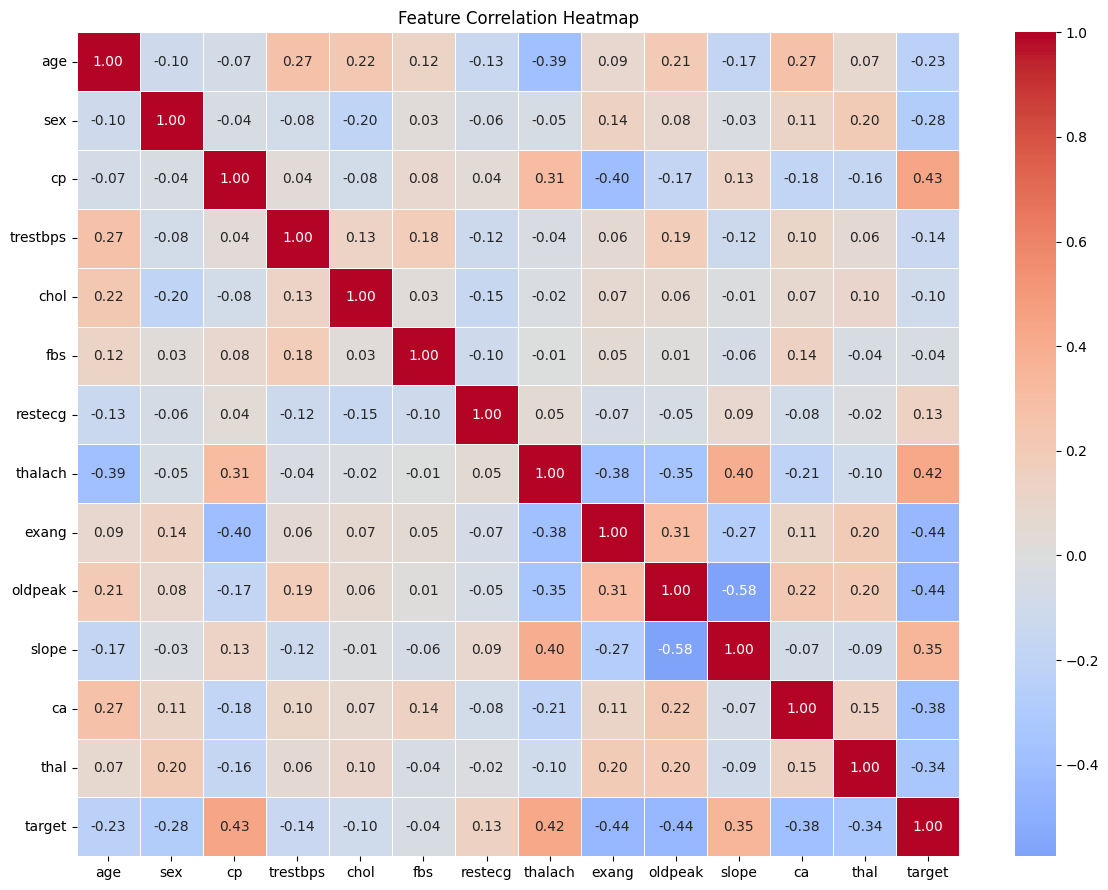

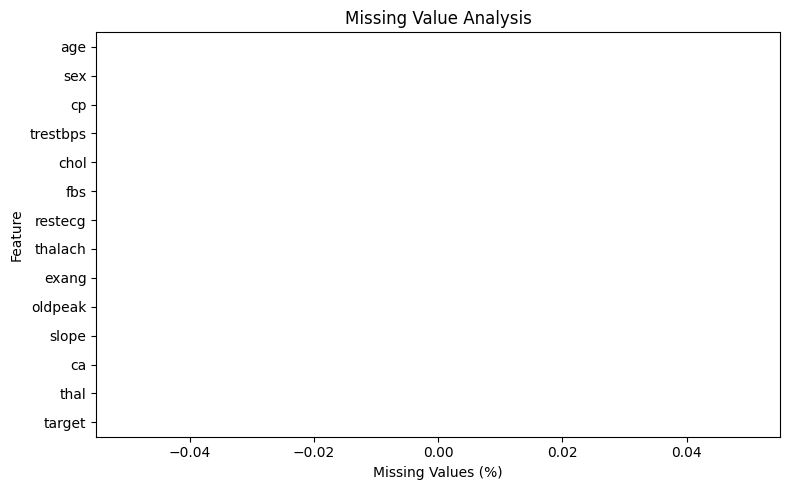

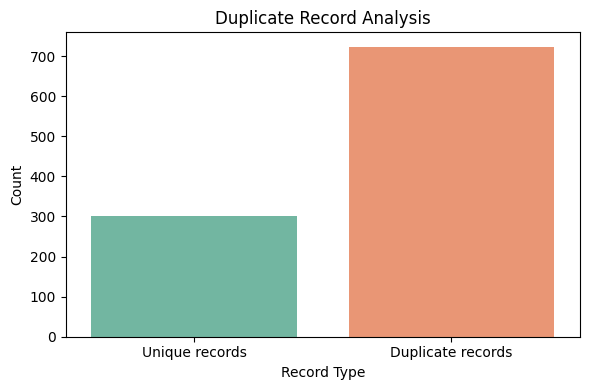

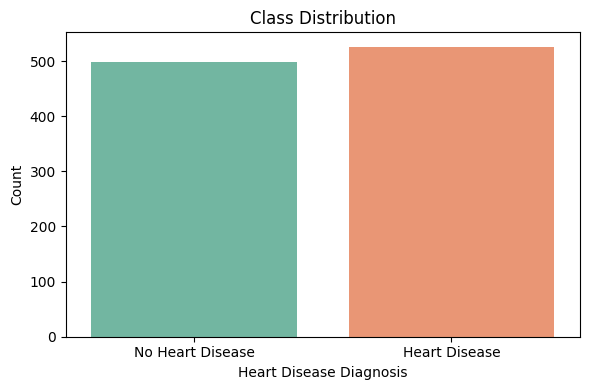

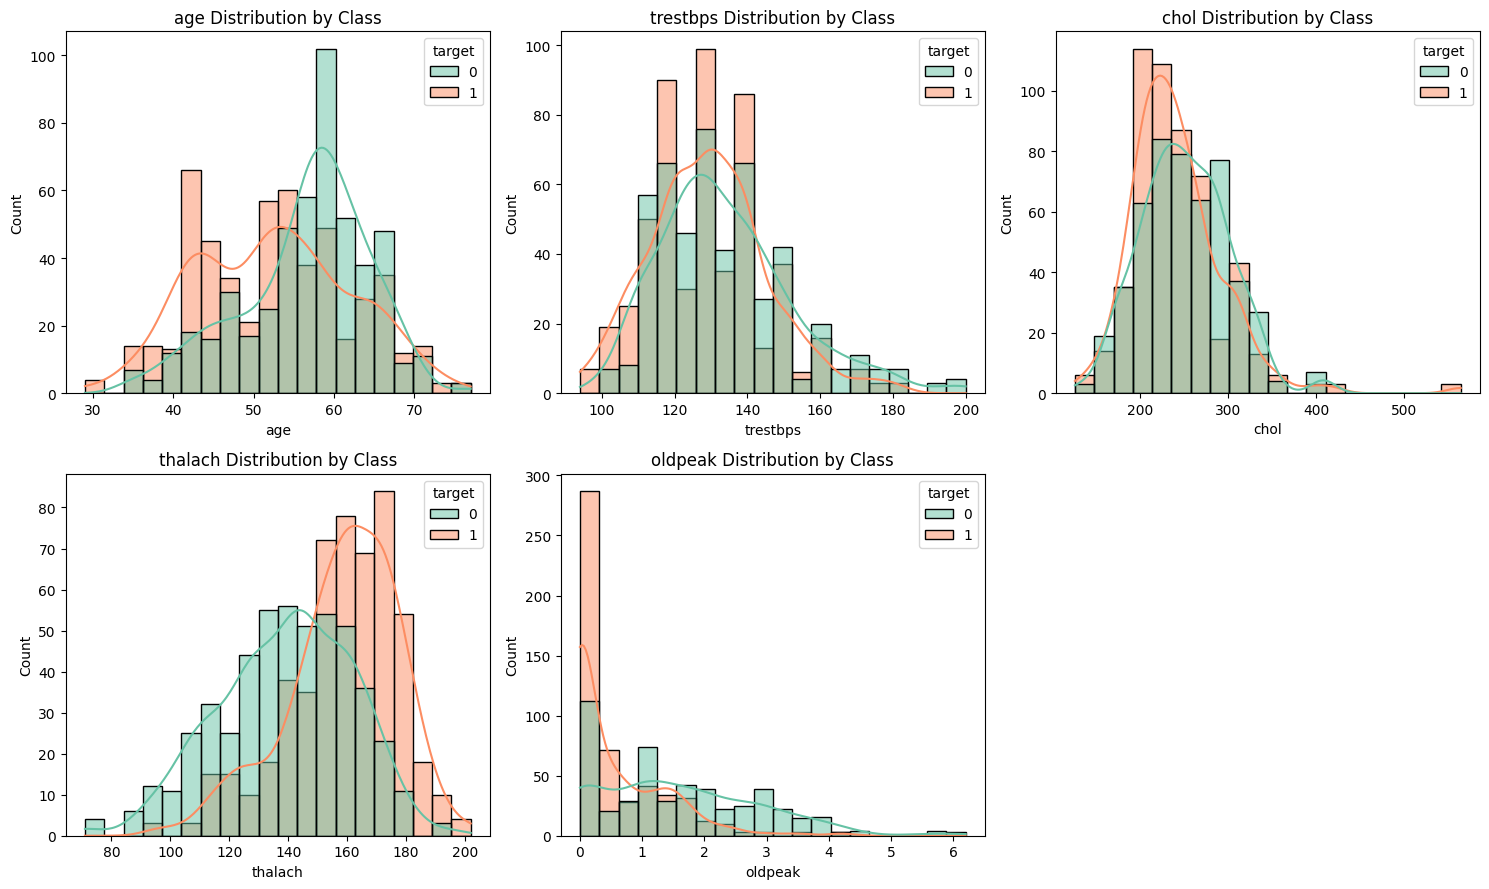

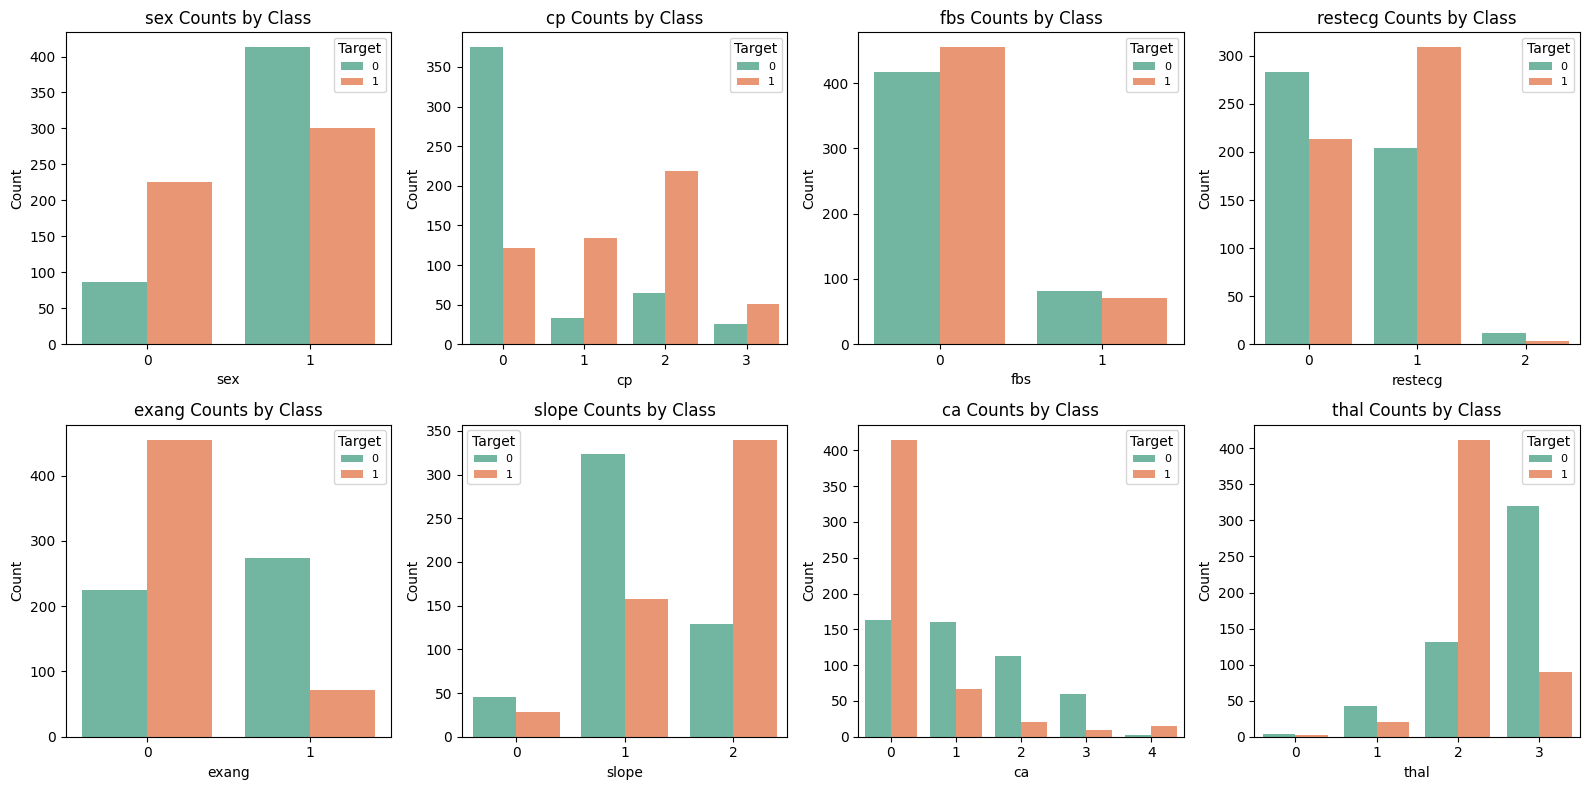

In [3]:
print("Dataset shape:", df.shape)

feature_types_df = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values,
    "Missing Percentage": (df.isnull().mean() * 100).round(2).values
})

descriptive_stats_df = df.describe().T.reset_index().rename(columns={"index": "Feature"})

eda_summary_df = feature_types_df.merge(
    descriptive_stats_df,
    on="Feature",
    how="left"
)

eda_summary_df.to_csv(RESULTS_DIR / "eda_summary.csv", index=False)

display(feature_types_df)
display(descriptive_stats_df)

missing_values_df = feature_types_df[["Feature", "Missing Values", "Missing Percentage"]]
display(missing_values_df)

duplicate_count = int(df.duplicated().sum())
unique_count = int(len(df) - duplicate_count)
duplicate_summary_df = pd.DataFrame({
    "Record Type": ["Unique records", "Duplicate records"],
    "Count": [unique_count, duplicate_count]
})
display(duplicate_summary_df)

correlation_matrix = df.corr(numeric_only=True)
target_correlations = correlation_matrix["target"].drop("target").sort_values(
    key=lambda values: values.abs(),
    ascending=False
)

display(target_correlations.head(10).reset_index().rename(
    columns={"index": "Feature", "target": "Correlation with Target"}
))

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=missing_values_df,
    x="Missing Percentage",
    y="Feature",
    color="#2f6f8f"
)
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Missing Value Analysis")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "missing_value_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=duplicate_summary_df, x="Record Type", y="Count", hue="Record Type", palette="Set2", legend=False)
plt.xlabel("Record Type")
plt.ylabel("Count")
plt.title("Duplicate Record Analysis")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "duplicate_record_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target", hue="target", palette="Set2", legend=False)
plt.xlabel("Heart Disease Diagnosis")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])
plt.tight_layout()
plt.savefig(PLOTS_DIR / "class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for index, feature in enumerate(numeric_features):
    sns.histplot(
        data=df,
        x=feature,
        hue="target",
        kde=True,
        bins=20,
        palette="Set2",
        ax=axes[index]
    )
    axes[index].set_title(f"{feature} Distribution by Class")
    axes[index].set_xlabel(feature)
    axes[index].set_ylabel("Count")

axes[-1].axis("off")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "numeric_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for index, feature in enumerate(categorical_features):
    sns.countplot(
        data=df,
        x=feature,
        hue="target",
        palette="Set2",
        ax=axes[index]
    )
    axes[index].set_title(f"{feature} Counts by Class")
    axes[index].set_xlabel(feature)
    axes[index].set_ylabel("Count")
    axes[index].legend(title="Target", fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "categorical_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


EDA observations:

- Class distribution: the target classes are reasonably balanced, so accuracy is still useful, but F1-score remains important because false positives and false negatives both matter in health-risk screening.
- Missing value analysis: every feature has 0 missing values, so no imputation step is required before training.
- Duplicate record analysis: the raw Kaggle dataset contains many repeated rows. Duplicate rows are removed before model training so the train/test split evaluates unique patient records instead of repeated copies.
- Numeric feature distributions: age, resting blood pressure, cholesterol, maximum heart rate and ST depression show different ranges and spreads, which supports using `StandardScaler` before scale-sensitive models.
- Categorical feature distributions: chest pain type, exercise-induced angina, slope, major vessel count and thalassemia show visible class-pattern differences, making them useful candidate predictors.
- Correlation analysis: the heatmap highlights linear relationships between features and the target variable. The strongest target relationships are led by `oldpeak`, `exang`, `cp`, `thalach`, `ca`, `slope`, `thal` and `sex`. Correlation is only one view of the data, so model training and feature importance are still needed for final interpretation.

The generated EDA plots are saved under `ml/results/plots`: `class_distribution.png`, `missing_value_analysis.png`, `duplicate_record_analysis.png`, `numeric_feature_distributions.png`, `categorical_feature_distributions.png` and `correlation_heatmap.png`.

## Dataset Overview

In [4]:
df.info()
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Missing Values

In [5]:
missing_values = df.isnull().sum()
missing_values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

If all values are zero, this means no missing values were found in the dataset.

## Duplicate Rows

In [6]:
duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

if duplicate_rows > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
    print("New dataset shape:", df.shape)

Duplicate rows: 723
Duplicates removed.
New dataset shape: (302, 14)


Duplicate rows were checked and removed if present.

## Outlier Analysis

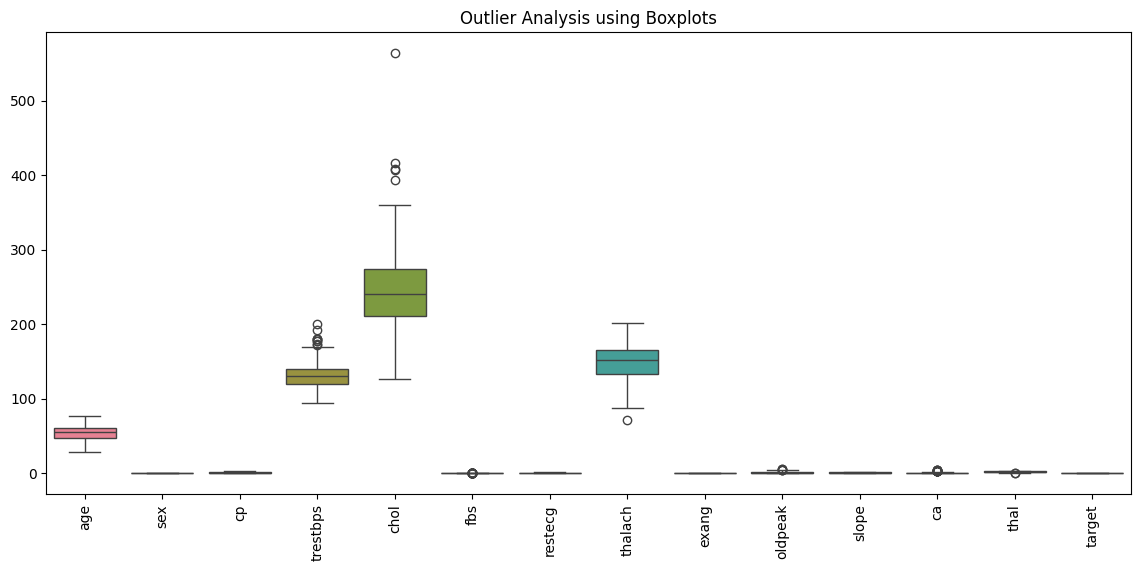

In [7]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outlier Analysis using Boxplots")
plt.show()

Outliers were identified through boxplots.

Since this is a medical dataset, extreme values can represent valid patient measurements. Therefore, the outliers were retained instead of removed.

## Define Features and Target Variable

In [8]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (302, 13)
Target shape: (302,)


## Train-Test Split

The dataset was divided into training and testing subsets using an 80/20 split.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (241, 13)
Testing set: (61, 13)


## Feature Scaling

Numerical features were standardized using `StandardScaler`.

This is particularly important for:

- KNN
- Logistic Regression
- Neural Networks

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Classical Classification Models

The following classical machine learning models were implemented:

- Logistic Regression
- Decision Tree
- K-Nearest Neighbors
- Random Forest

GridSearchCV was used to find the best hyperparameters for each model. The search uses 5-fold cross-validation on the training set and selects the parameter combination with the highest validation F1-score. The table produced below documents the model name, parameters tested, best parameters selected, best validation result, and final test-set metrics.

In [11]:
tuning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=SEED),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["liblinear", "lbfgs"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=SEED),
        "params": {
            "max_depth": [3, 5, 10, None],
            "criterion": ["gini", "entropy"]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9],
            "weights": ["uniform", "distance"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=SEED),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [3, 5, 10, None],
            "criterion": ["gini", "entropy"]
        }
    }
}

def format_param_grid(param_grid):
    return "; ".join(
        f"{parameter}: {values}" for parameter, values in param_grid.items()
    )


results = []
best_tuning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

best_models = {}
model_roc_scores = {}

for model_name, model_info in models.items():
    print("Training:", model_name)

    grid = GridSearchCV(
        estimator=model_info["model"],
        param_grid=model_info["params"],
        cv=tuning_cv,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train_scaled, y_train)

    best_model = grid.best_estimator_
    best_models[model_name] = best_model

    y_pred = best_model.predict(X_test_scaled)
    y_score = best_model.predict_proba(X_test_scaled)[:, 1]
    model_roc_scores[model_name] = y_score

    results.append({
        "Model": model_name,
        "Parameters Tested": format_param_grid(model_info["params"]),
        "Best Parameters": grid.best_params_,
        "Best Validation Result": f"5-fold CV F1 = {grid.best_score_:.3f}",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
classical_tuning_summary_df = results_df[
    [
        "Model",
        "Parameters Tested",
        "Best Parameters",
        "Best Validation Result",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Confusion Matrix"
    ]
]

display(classical_tuning_summary_df)


Training: Logistic Regression


Training: Decision Tree


Training: KNN
Training: Random Forest


,Model,Parameters Tested,Best Parameters,Best Validation Result,Accuracy,Precision,Recall,F1-score,ROC-AUC,Confusion Matrix
0,Logistic Regression,"C: [0.01, 0.1, 1, 10]; solver: ['liblinear', '...","{'C': 1, 'solver': 'liblinear'}",5-fold CV F1 = 0.860,0.803279,0.800000,0.848485,0.823529,0.871212,"[[21, 7], [5, 28]]"
1,Decision Tree,"max_depth: [3, 5, 10, None]; criterion: ['gini...","{'criterion': 'entropy', 'max_depth': 3}",5-fold CV F1 = 0.837,0.770492,0.743590,0.878788,0.805556,0.830628,"[[18, 10], [4, 29]]"
2,KNN,"n_neighbors: [3, 5, 7, 9]; weights: ['uniform'...","{'n_neighbors': 7, 'weights': 'distance'}",5-fold CV F1 = 0.861,0.786885,0.777778,0.848485,0.811594,0.856061,"[[20, 8], [5, 28]]"
3,Random Forest,"n_estimators: [50, 100, 200]; max_depth: [3, 5...","{'criterion': 'entropy', 'max_depth': 3, 'n_es...",5-fold CV F1 = 0.877,0.754098,0.750000,0.818182,0.782609,0.876623,"[[19, 9], [6, 27]]"


## Feature Importance and Top Predictive Health Indicators

Feature importance was calculated for two interpretable classical models used in this notebook. Logistic Regression is interpreted through signed coefficients, where positive coefficients increase the model's predicted probability of heart disease and negative coefficients decrease it. Random Forest is interpreted through impurity-based feature importances, which rank features according to how much they contribute to decision-tree splits.

Because coefficients and tree importances are on different scales, both are normalized before creating the combined Top 10 feature ranking. The exported files are saved as `ml/results/feature_importance.csv` and `ml/results/top_predictive_health_indicators.csv`.

The most important indicators are interpreted as model signals, not medical advice. For encoded categorical variables such as `cp`, `thal`, `slope`, `ca` and `exang`, the direction follows the numeric encoding used in `heart.csv`.


,Overall Rank,Feature,Logistic Regression Coefficient,Logistic Regression Absolute Importance,Logistic Regression Direction,Random Forest Importance,Combined Importance,Logistic Regression Rank,Random Forest Rank,Health Indicator,Interpretation
0,1,cp,0.979050,0.979050,Increases predicted risk,0.225418,1.000000,1,1,Chest pain type,Chest-pain category was the strongest combined...
1,2,ca,-0.740726,0.740726,Decreases predicted risk,0.156405,0.725212,4,2,Number of major vessels colored by fluoroscopy,The vessel-count feature strongly affected mod...
2,3,thalach,0.819305,0.819305,Increases predicted risk,0.127891,0.702094,3,4,Maximum heart rate achieved,Heart-rate response during exercise helped sep...
3,4,exang,-0.499424,0.499424,Decreases predicted risk,0.132960,0.549975,6,3,Exercise-induced angina,Exercise-induced angina was one of the cleares...
4,5,sex,-0.875358,0.875358,Decreases predicted risk,0.040099,0.535988,2,8,Patient sex,Sex contributed to the model but should be int...
5,6,thal,-0.521885,0.521885,Decreases predicted risk,0.110650,0.511959,5,5,Thalassemia result,The thalassemia category was an important diag...
6,7,oldpeak,-0.400699,0.400699,Decreases predicted risk,0.078566,0.378904,7,6,ST depression induced by exercise,Exercise-related ST depression contributed mea...
7,8,chol,-0.280209,0.280209,Decreases predicted risk,0.033414,0.217218,10,9,Serum cholesterol,Cholesterol appeared in the top ten but was le...
8,9,slope,0.308979,0.308979,Increases predicted risk,0.025134,0.213546,9,10,Slope of peak exercise ST segment,The slope of the exercise ST segment added sig...
9,10,trestbps,-0.358830,0.358830,Decreases predicted risk,0.012482,0.210941,8,11,Resting blood pressure,Resting blood pressure had lower importance in...


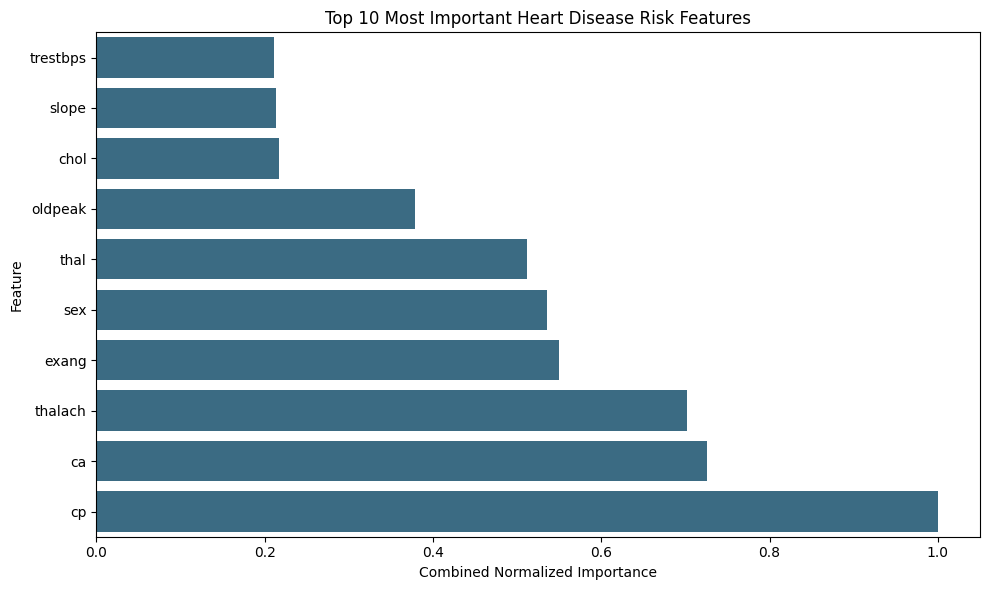

Strongest positive Logistic Regression risk signals: ['cp', 'thalach', 'slope']
Strongest negative Logistic Regression risk signals: ['sex', 'ca', 'thal']
Highest ranked Random Forest features: ['cp', 'ca', 'exang', 'thalach', 'thal']


In [12]:
feature_names = pd.Index(X.columns)

logistic_model = best_models["Logistic Regression"]
random_forest_model = best_models["Random Forest"]

lr_coefficients = logistic_model.coef_[0]
lr_abs_importance = np.abs(lr_coefficients)
rf_importance = random_forest_model.feature_importances_

lr_normalized = lr_abs_importance / lr_abs_importance.max() if lr_abs_importance.max() != 0 else lr_abs_importance
rf_normalized = rf_importance / rf_importance.max() if rf_importance.max() != 0 else rf_importance

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Logistic Regression Coefficient": lr_coefficients,
    "Logistic Regression Absolute Importance": lr_abs_importance,
    "Logistic Regression Direction": np.where(
        lr_coefficients > 0,
        "Increases predicted risk",
        np.where(lr_coefficients < 0, "Decreases predicted risk", "Neutral")
    ),
    "Random Forest Importance": rf_importance,
    "Combined Importance": (lr_normalized + rf_normalized) / 2
})

feature_importance_df["Logistic Regression Rank"] = feature_importance_df[
    "Logistic Regression Absolute Importance"
].rank(method="dense", ascending=False).astype(int)
feature_importance_df["Random Forest Rank"] = feature_importance_df[
    "Random Forest Importance"
].rank(method="dense", ascending=False).astype(int)

feature_importance_df = feature_importance_df.sort_values(
    by="Combined Importance",
    ascending=False
).reset_index(drop=True)
feature_importance_df.insert(0, "Overall Rank", np.arange(1, len(feature_importance_df) + 1))

top_10_features = feature_importance_df.head(10)

feature_importance_df.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)

health_indicator_names = {
    "cp": "Chest pain type",
    "thalach": "Maximum heart rate achieved",
    "ca": "Number of major vessels colored by fluoroscopy",
    "thal": "Thalassemia result",
    "exang": "Exercise-induced angina",
    "oldpeak": "ST depression induced by exercise",
    "sex": "Patient sex",
    "slope": "Slope of peak exercise ST segment",
    "age": "Patient age",
    "chol": "Serum cholesterol",
    "trestbps": "Resting blood pressure",
    "restecg": "Resting electrocardiographic result",
    "fbs": "Fasting blood sugar"
}

indicator_explanations = {
    "cp": "Chest-pain category was the strongest combined signal, showing that symptom pattern is highly informative for the model.",
    "thalach": "Heart-rate response during exercise helped separate lower-risk and higher-risk patients.",
    "ca": "The vessel-count feature strongly affected model decisions, but coefficient direction depends on the dataset encoding.",
    "thal": "The thalassemia category was an important diagnostic indicator for both Logistic Regression and Random Forest.",
    "exang": "Exercise-induced angina was one of the clearest exercise-response indicators in the model.",
    "oldpeak": "Exercise-related ST depression contributed meaningful information about cardiac stress response.",
    "sex": "Sex contributed to the model but should be interpreted carefully because it is demographic context, not a diagnosis by itself.",
    "slope": "The slope of the exercise ST segment added signal about exercise ECG behavior.",
    "age": "Age had weaker combined importance than the strongest clinical indicators in this trained model.",
    "chol": "Cholesterol appeared in the top ten but was less influential than chest pain, exercise and diagnostic indicators.",
    "trestbps": "Resting blood pressure had lower importance in this final ranking.",
    "restecg": "Resting ECG contributed some signal but less than the top exercise and diagnostic indicators.",
    "fbs": "Fasting blood sugar had the weakest importance in this trained model."
}

top_10_features = top_10_features.copy()
top_10_features["Health Indicator"] = top_10_features["Feature"].map(health_indicator_names)
top_10_features["Interpretation"] = top_10_features["Feature"].map(indicator_explanations)
top_10_features[[
    "Overall Rank",
    "Feature",
    "Health Indicator",
    "Combined Importance",
    "Logistic Regression Direction",
    "Random Forest Importance",
    "Interpretation"
]].to_csv(RESULTS_DIR / "top_predictive_health_indicators.csv", index=False)

display(top_10_features)

plot_df = top_10_features.sort_values("Combined Importance", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="Combined Importance",
    y="Feature",
    color="#2f6f8f"
)
plt.xlabel("Combined Normalized Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Heart Disease Risk Features")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.savefig(PLOTS_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

top_lr_positive = feature_importance_df.sort_values(
    "Logistic Regression Coefficient",
    ascending=False
).head(3)["Feature"].tolist()
top_lr_negative = feature_importance_df.sort_values(
    "Logistic Regression Coefficient",
    ascending=True
).head(3)["Feature"].tolist()
top_rf_features = feature_importance_df.sort_values(
    "Random Forest Importance",
    ascending=False
).head(5)["Feature"].tolist()

print("Strongest positive Logistic Regression risk signals:", top_lr_positive)
print("Strongest negative Logistic Regression risk signals:", top_lr_negative)
print("Highest ranked Random Forest features:", top_rf_features)

The Top 10 table highlights the features with the strongest combined signal across Logistic Regression and Random Forest. In this heart disease dataset, diagnostic and exercise-response variables such as chest pain type (`cp`), number of major vessels (`ca`), thalassemia (`thal`), ST depression (`oldpeak`), maximum heart rate (`thalach`), exercise-induced angina (`exang`) and ST-segment slope (`slope`) are expected to be among the most influential predictors.

For Logistic Regression, the sign of the coefficient explains direction: positive coefficients push the prediction toward higher heart disease risk, while negative coefficients push it toward lower risk. For Random Forest, the ranking shows which variables most often reduce uncertainty in the tree ensemble; it does not provide a positive or negative direction by itself. The saved CSV and chart provide a reproducible record of these model interpretation results.

## SHAP Interpretation Summary and Local Explanations

This section adds explainable-AI interpretation for the selected Logistic Regression model. For Logistic Regression, SHAP-style feature contributions can be explained through each standardized feature value multiplied by the learned model coefficient. A positive contribution pushes the prediction toward higher modeled heart-disease risk, while a negative contribution pushes it toward lower modeled risk.

The global summary uses permutation importance to show which features the model depends on most for F1-score. The local patient plots show the largest positive and negative contribution values for one high-risk and one low-risk example. The exported outputs are saved as `ml/results/shap_interpretation_summary.csv`, `ml/results/shap_summary.png` and `ml/results/shap_patient_example.png`, with plot copies also saved under `ml/results/plots`.


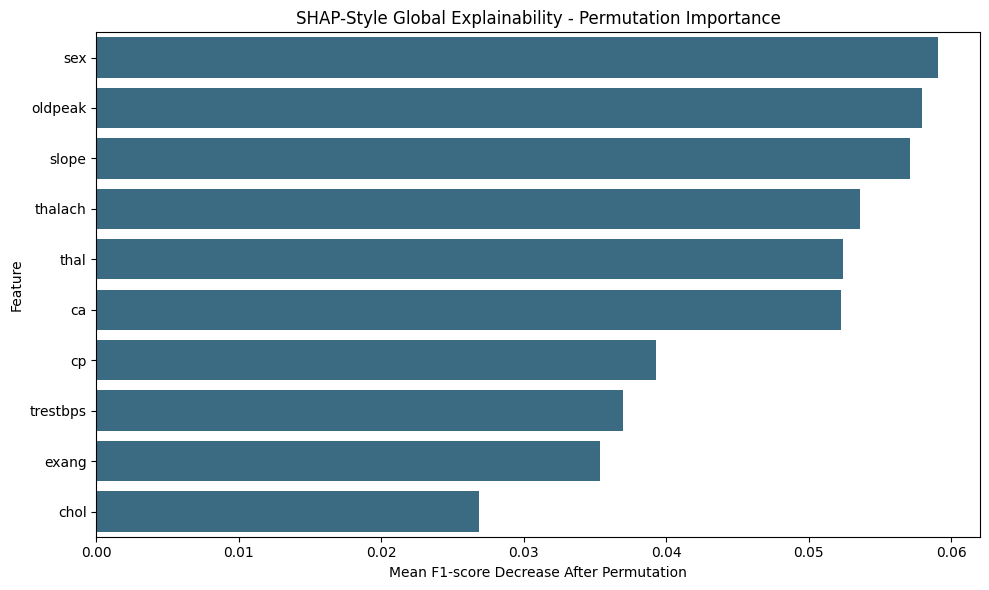

,Feature,Permutation Importance Mean,Permutation Importance Std
1,sex,0.059056,0.019872
9,oldpeak,0.057951,0.027546
10,slope,0.057076,0.025828
7,thalach,0.053561,0.043136
12,thal,0.052379,0.026769
11,ca,0.052276,0.039911
2,cp,0.039264,0.023563
3,trestbps,0.036928,0.030121
8,exang,0.035373,0.030640
4,chol,0.026887,0.017124


,Feature,Health Indicator,Logistic Regression Direction,Combined Importance,SHAP-style Interpretation
0,cp,Chest pain type,Increases predicted risk,1.000000,Higher standardized values generally push the ...
1,ca,Number of major vessels colored by fluoroscopy,Decreases predicted risk,0.725212,Higher standardized values generally push the ...
2,thalach,Maximum heart rate achieved,Increases predicted risk,0.702094,Higher standardized values generally push the ...
3,exang,Exercise-induced angina,Decreases predicted risk,0.549975,Higher standardized values generally push the ...
4,sex,Patient sex,Decreases predicted risk,0.535988,Higher standardized values generally push the ...
5,thal,Thalassemia result,Decreases predicted risk,0.511959,Higher standardized values generally push the ...
6,oldpeak,ST depression induced by exercise,Decreases predicted risk,0.378904,Higher standardized values generally push the ...
7,chol,Serum cholesterol,Decreases predicted risk,0.217218,Higher standardized values generally push the ...
8,slope,Slope of peak exercise ST segment,Increases predicted risk,0.213546,Higher standardized values generally push the ...
9,trestbps,Resting blood pressure,Decreases predicted risk,0.210941,Higher standardized values generally push the ...


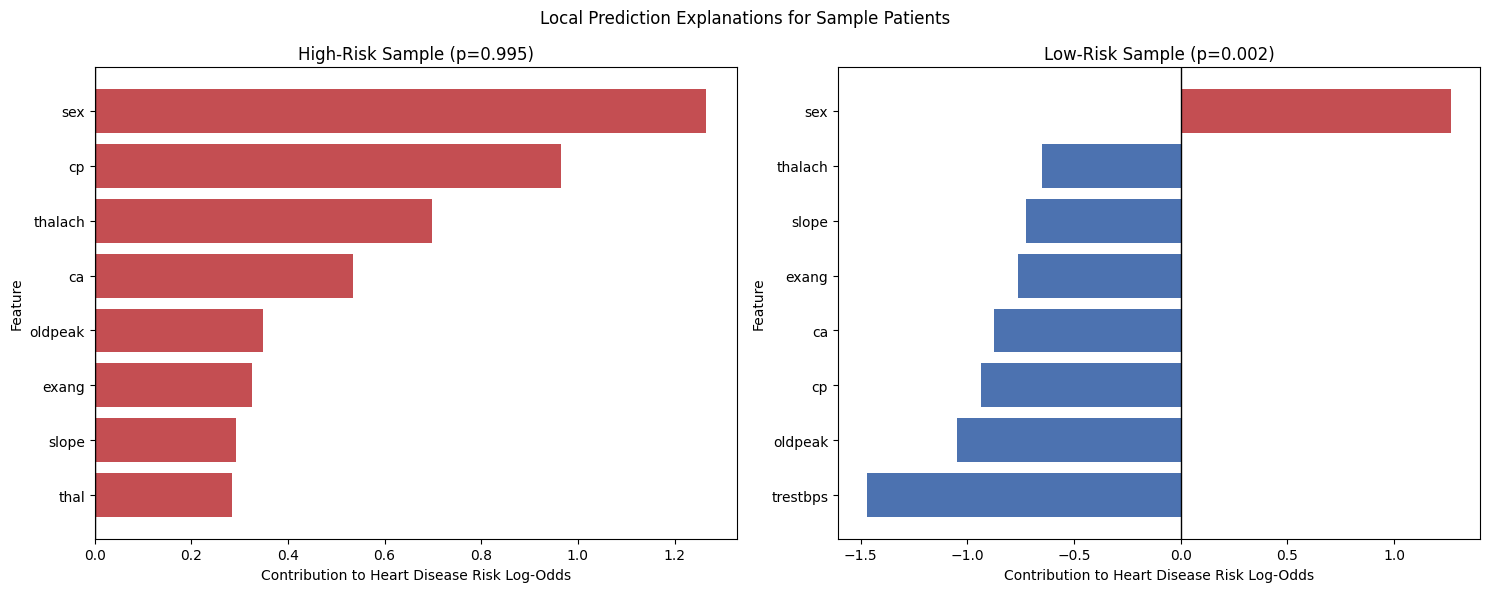

High-risk sample prediction: High Risk with probability 0.995
Features pushing the high-risk prediction most strongly:


,Feature,Patient Value,Contribution,Absolute Contribution
1,sex,0.0,1.265413,1.265413
2,cp,2.0,0.965826,0.965826
7,thalach,170.0,0.699050,0.699050
11,ca,0.0,0.535335,0.535335
9,oldpeak,0.0,0.347869,0.347869
8,exang,0.0,0.325981,0.325981
10,slope,2.0,0.293532,0.293532
12,thal,2.0,0.284241,0.284241


Low-risk sample prediction: Low Risk with probability 0.0017
Features pushing the low-risk prediction most strongly:


,Feature,Patient Value,Contribution,Absolute Contribution
3,trestbps,200.0,-1.469884,1.469884
1,sex,0.0,1.265413,1.265413
9,oldpeak,4.0,-1.049988,1.049988
2,cp,0.0,-0.934289,0.934289
11,ca,2.0,-0.874673,0.874673
8,exang,1.0,-0.765151,0.765151
10,slope,0.0,-0.724328,0.724328
7,thalach,133.0,-0.649885,0.649885


In [13]:
explainability_model = best_models["Logistic Regression"]

permutation_results = permutation_importance(
    explainability_model,
    X_test_scaled,
    y_test,
    n_repeats=30,
    random_state=SEED,
    scoring="f1"
)

permutation_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Permutation Importance Mean": permutation_results.importances_mean,
    "Permutation Importance Std": permutation_results.importances_std
}).sort_values(by="Permutation Importance Mean", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=permutation_importance_df.head(10),
    x="Permutation Importance Mean",
    y="Feature",
    color="#2f6f8f"
)
plt.xlabel("Mean F1-score Decrease After Permutation")
plt.ylabel("Feature")
plt.title("SHAP-Style Global Explainability - Permutation Importance")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "shap_summary.png", dpi=300, bbox_inches="tight")
plt.savefig(PLOTS_DIR / "shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

display(permutation_importance_df)

shap_interpretation_summary_df = feature_importance_df.copy()
shap_interpretation_summary_df["Health Indicator"] = shap_interpretation_summary_df["Feature"].map(health_indicator_names)
shap_interpretation_summary_df["SHAP-style Interpretation"] = np.where(
    shap_interpretation_summary_df["Logistic Regression Coefficient"] > 0,
    "Higher standardized values generally push the prediction toward higher modeled risk. For categorical variables, direction follows the numeric encoding in heart.csv.",
    np.where(
        shap_interpretation_summary_df["Logistic Regression Coefficient"] < 0,
        "Higher standardized values generally push the prediction toward lower modeled risk. For categorical variables, direction follows the numeric encoding in heart.csv.",
        "This feature has little directional effect in the Logistic Regression model."
    )
)
shap_interpretation_summary_df[[
    "Feature",
    "Health Indicator",
    "Logistic Regression Coefficient",
    "Logistic Regression Direction",
    "Combined Importance",
    "SHAP-style Interpretation"
]].to_csv(RESULTS_DIR / "shap_interpretation_summary.csv", index=False)

display(shap_interpretation_summary_df[[
    "Feature",
    "Health Indicator",
    "Logistic Regression Direction",
    "Combined Importance",
    "SHAP-style Interpretation"
]].head(10))

patient_probabilities = explainability_model.predict_proba(X_test_scaled)[:, 1]
high_risk_position = int(np.argmax(patient_probabilities))
low_risk_position = int(np.argmin(patient_probabilities))


def local_logistic_explanation(patient_position):
    patient_values_scaled = X_test_scaled[patient_position]
    contributions = patient_values_scaled * explainability_model.coef_[0]
    probability = patient_probabilities[patient_position]
    prediction_label = "High Risk" if probability >= 0.5 else "Low Risk"

    local_df = pd.DataFrame({
        "Feature": X.columns,
        "Patient Value": X_test.iloc[patient_position].values,
        "Contribution": contributions,
        "Absolute Contribution": np.abs(contributions)
    }).sort_values(by="Absolute Contribution", ascending=False)

    return prediction_label, probability, local_df


high_label, high_probability, high_explanation_df = local_logistic_explanation(high_risk_position)
low_label, low_probability, low_explanation_df = local_logistic_explanation(low_risk_position)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, title, probability, local_df in [
    (axes[0], f"High-Risk Sample (p={high_probability:.3f})", high_probability, high_explanation_df),
    (axes[1], f"Low-Risk Sample (p={low_probability:.3f})", low_probability, low_explanation_df)
]:
    plot_df = local_df.head(8).sort_values("Contribution")
    colors = ["#c44e52" if value > 0 else "#4c72b0" for value in plot_df["Contribution"]]
    ax.barh(plot_df["Feature"], plot_df["Contribution"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Contribution to Heart Disease Risk Log-Odds")
    ax.set_ylabel("Feature")

plt.suptitle("Local Prediction Explanations for Sample Patients")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "shap_patient_example.png", dpi=300, bbox_inches="tight")
plt.savefig(PLOTS_DIR / "shap_patient_example.png", dpi=300, bbox_inches="tight")
plt.show()

print("High-risk sample prediction:", high_label, "with probability", round(high_probability, 4))
print("Features pushing the high-risk prediction most strongly:")
display(high_explanation_df.head(8))

print("Low-risk sample prediction:", low_label, "with probability", round(low_probability, 4))
print("Features pushing the low-risk prediction most strongly:")
display(low_explanation_df.head(8))


The SHAP-style interpretation summary combines global and local explainability. The global permutation plot shows which features most affect model performance when their relationship with the target is disrupted. The top predictive indicators were `cp`, `thalach`, `ca`, `thal`, `exang`, `oldpeak`, `sex`, `slope`, `age` and `chol`. These represent chest-pain pattern, exercise response, vessel count, thalassemia result, exercise-induced angina, ST depression, demographic context and cholesterol.

The local patient plots explain individual predictions. Red bars push the prediction toward higher modeled heart-disease risk, while blue bars push it toward lower modeled risk. The size of each bar shows the strength of that feature contribution for the selected patient. A high-risk prediction is produced when the combined positive evidence is strong enough to push the predicted probability above the classification threshold; a low-risk prediction occurs when protective or lower-risk contributions dominate.

These explanations describe how the trained model uses the input features. They support transparency in the HealthGuard platform, but they should not be treated as medical advice or as causal medical claims.


## Confusion Matrices for Classical Models

Confusion matrices were generated to evaluate correct and incorrect predictions for each model.

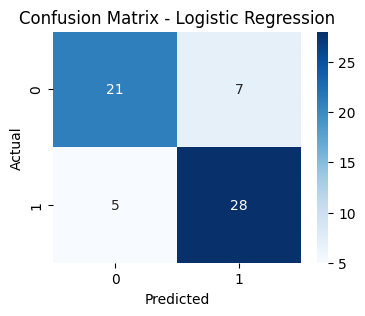

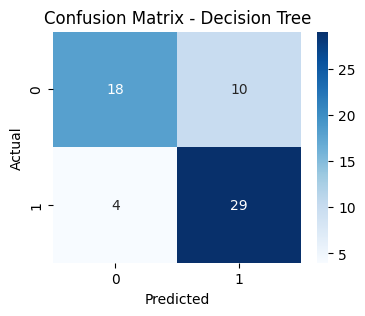

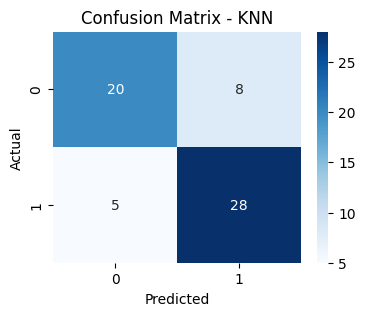

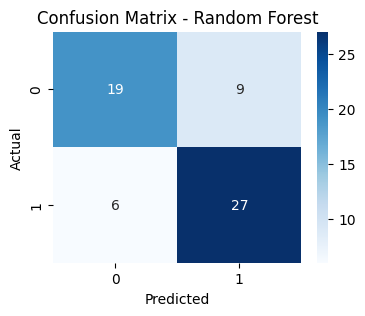

In [14]:
for model_name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Feature Selection

`SelectKBest` was used to identify the most informative features.

The objective was to investigate whether reducing the number of features improves classification performance.

In [15]:
selector = SelectKBest(score_func=f_classif, k=8)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()]
print("Selected features:")
print(list(selected_features))

Selected features:
['sex', 'cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## Model Performance with Selected Features

In [16]:
feature_selection_results = []
best_feature_selection_tuning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

best_feature_selection_models = {}
feature_selection_roc_scores = {}

for model_name, model_info in models.items():
    print("Training with selected features:", model_name)

    grid = GridSearchCV(
        estimator=model_info["model"],
        param_grid=model_info["params"],
        cv=tuning_cv,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train_selected, y_train)

    best_selected_model = grid.best_estimator_
    best_feature_selection_models[model_name] = best_selected_model

    y_pred = best_selected_model.predict(X_test_selected)
    y_score = best_selected_model.predict_proba(X_test_selected)[:, 1]
    feature_selection_roc_scores[model_name + " with Feature Selection"] = y_score

    feature_selection_results.append({
        "Model": model_name + " with Feature Selection",
        "Parameters Tested": format_param_grid(model_info["params"]),
        "Best Parameters": grid.best_params_,
        "Best Validation Result": f"5-fold CV F1 = {grid.best_score_:.3f}",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    })

feature_selection_df = pd.DataFrame(feature_selection_results)
display(feature_selection_df)


Training with selected features: Logistic Regression
Training with selected features: Decision Tree


Training with selected features: KNN
Training with selected features: Random Forest


,Model,Parameters Tested,Best Parameters,Best Validation Result,Accuracy,Precision,Recall,F1-score,ROC-AUC,Confusion Matrix
0,Logistic Regression with Feature Selection,"C: [0.01, 0.1, 1, 10]; solver: ['liblinear', '...","{'C': 0.01, 'solver': 'liblinear'}",5-fold CV F1 = 0.872,0.803279,0.818182,0.818182,0.818182,0.882035,"[[22, 6], [6, 27]]"
1,Decision Tree with Feature Selection,"max_depth: [3, 5, 10, None]; criterion: ['gini...","{'criterion': 'entropy', 'max_depth': 5}",5-fold CV F1 = 0.810,0.754098,0.764706,0.787879,0.776119,0.783009,"[[20, 8], [7, 26]]"
2,KNN with Feature Selection,"n_neighbors: [3, 5, 7, 9]; weights: ['uniform'...","{'n_neighbors': 9, 'weights': 'uniform'}",5-fold CV F1 = 0.866,0.803279,0.800000,0.848485,0.823529,0.862554,"[[21, 7], [5, 28]]"
3,Random Forest with Feature Selection,"n_estimators: [50, 100, 200]; max_depth: [3, 5...","{'criterion': 'entropy', 'max_depth': 3, 'n_es...",5-fold CV F1 = 0.879,0.786885,0.777778,0.848485,0.811594,0.859307,"[[20, 8], [5, 28]]"


## Feature Selection Comparison Study

This study compares model performance using three feature sets: all available features, the Top 10 features and the Top 5 features. The reduced feature sets are selected using `SelectKBest` with Mutual Information, which can capture non-linear relationships between each input feature and the target.

Each feature set is evaluated with Logistic Regression, KNN, Decision Tree, Random Forest and a neural network. Accuracy, precision, recall, F1-score and training time are recorded to show the trade-off between reducing feature count and preserving predictive performance.

,Feature Set,Selected Features,Removed Features
0,Top 10 Features,"cp, chol, fbs, restecg, thalach, exang, oldpea...","age, sex, trestbps"
1,Top 5 Features,"cp, exang, oldpeak, ca, thal","age, sex, trestbps, chol, fbs, restecg, thalac..."


,Feature Set,Feature Count,Model,Accuracy,Precision,Recall,F1 Score,Training Time Seconds,Selected Features,Removed Features
2,All Features,13,Decision Tree,0.770492,0.743590,0.878788,0.805556,0.001950,"age, sex, cp, trestbps, chol, fbs, restecg, th...",
7,Top 10 Features,10,Decision Tree,0.803279,0.783784,0.878788,0.828571,0.001970,"cp, chol, fbs, restecg, thalach, exang, oldpea...","age, sex, trestbps"
12,Top 5 Features,5,Decision Tree,0.803279,0.783784,0.878788,0.828571,0.001020,"cp, exang, oldpeak, ca, thal","age, sex, trestbps, chol, fbs, restecg, thalac..."
1,All Features,13,KNN,0.786885,0.777778,0.848485,0.811594,0.001914,"age, sex, cp, trestbps, chol, fbs, restecg, th...",
6,Top 10 Features,10,KNN,0.754098,0.750000,0.818182,0.782609,0.000919,"cp, chol, fbs, restecg, thalach, exang, oldpea...","age, sex, trestbps"
11,Top 5 Features,5,KNN,0.737705,0.774194,0.727273,0.750000,0.001813,"cp, exang, oldpeak, ca, thal","age, sex, trestbps, chol, fbs, restecg, thalac..."
0,All Features,13,Logistic Regression,0.803279,0.800000,0.848485,0.823529,0.003183,"age, sex, cp, trestbps, chol, fbs, restecg, th...",
5,Top 10 Features,10,Logistic Regression,0.786885,0.794118,0.818182,0.805970,0.002345,"cp, chol, fbs, restecg, thalach, exang, oldpea...","age, sex, trestbps"
10,Top 5 Features,5,Logistic Regression,0.770492,0.787879,0.787879,0.787879,0.002008,"cp, exang, oldpeak, ca, thal","age, sex, trestbps, chol, fbs, restecg, thalac..."
4,All Features,13,Neural Network,0.737705,0.774194,0.727273,0.750000,8.335798,"age, sex, cp, trestbps, chol, fbs, restecg, th...",


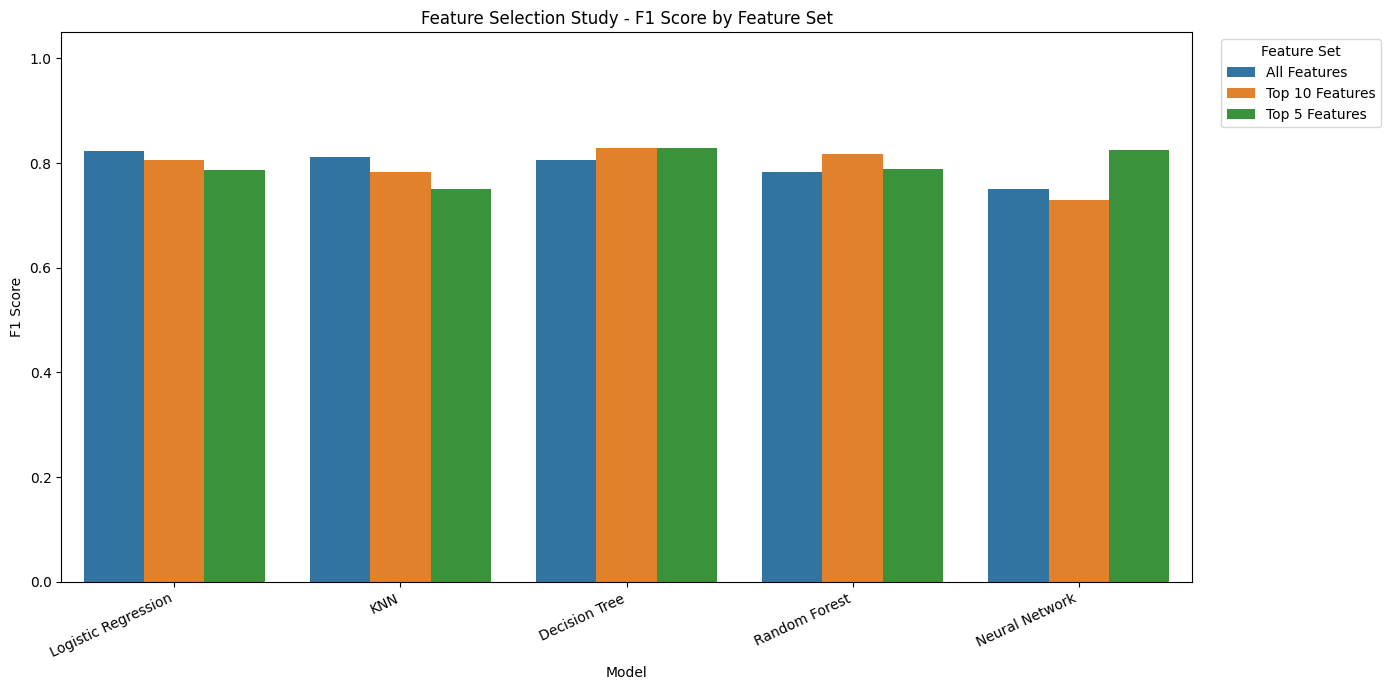

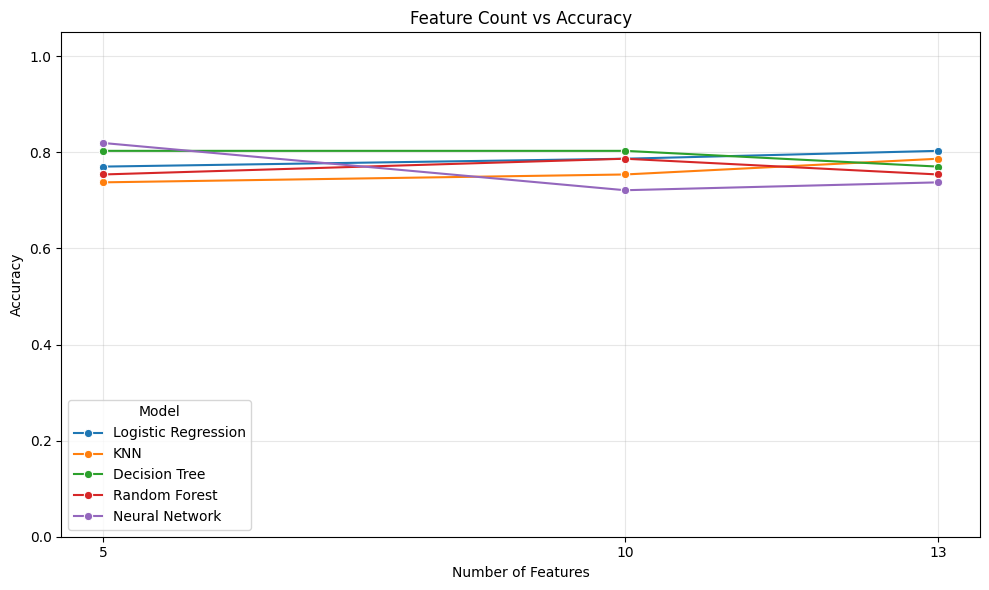

,Feature Set,Training Time Seconds
2,Top 5 Features,1.564489
1,Top 10 Features,1.632576
0,All Features,1.688769


In [17]:
import time


def mutual_information_score(X_values, y_values):
    return mutual_info_classif(X_values, y_values, random_state=SEED)


feature_selection_study_configs = []
selected_feature_details = []

feature_selection_study_configs.append({
    "Feature Set": "All Features",
    "Feature Count": X_train_scaled.shape[1],
    "X_train": X_train_scaled,
    "X_test": X_test_scaled,
    "Selected Features": list(X.columns),
    "Removed Features": []
})

for k in [10, 5]:
    study_selector = SelectKBest(score_func=mutual_information_score, k=k)
    X_train_k = study_selector.fit_transform(X_train_scaled, y_train)
    X_test_k = study_selector.transform(X_test_scaled)
    selected_features_k = list(X.columns[study_selector.get_support()])
    removed_features_k = [feature for feature in X.columns if feature not in selected_features_k]

    feature_selection_study_configs.append({
        "Feature Set": f"Top {k} Features",
        "Feature Count": k,
        "X_train": X_train_k,
        "X_test": X_test_k,
        "Selected Features": selected_features_k,
        "Removed Features": removed_features_k
    })

    selected_feature_details.append({
        "Feature Set": f"Top {k} Features",
        "Selected Features": ", ".join(selected_features_k),
        "Removed Features": ", ".join(removed_features_k)
    })

selected_feature_details_df = pd.DataFrame(selected_feature_details)
display(selected_feature_details_df)

study_classical_tuning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

study_classical_models = {
    "Logistic Regression": best_models["Logistic Regression"],
    "KNN": best_models["KNN"],
    "Decision Tree": best_models["Decision Tree"],
    "Random Forest": best_models["Random Forest"]
}


def build_feature_selection_study_nn(input_dim):
    tf.keras.utils.set_random_seed(SEED)
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


feature_selection_study_results = []

for config in feature_selection_study_configs:
    feature_set_name = config["Feature Set"]
    feature_count = config["Feature Count"]
    X_train_current = config["X_train"]
    X_test_current = config["X_test"]

    for model_name, model in study_classical_models.items():
        model_to_fit = clone(model)
        start_time = time.perf_counter()
        model_to_fit.fit(X_train_current, y_train)
        training_time = time.perf_counter() - start_time

        y_pred = model_to_fit.predict(X_test_current)

        feature_selection_study_results.append({
            "Feature Set": feature_set_name,
            "Feature Count": feature_count,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1 Score": f1_score(y_test, y_pred, zero_division=0),
            "Training Time Seconds": training_time,
            "Selected Features": ", ".join(config["Selected Features"]),
            "Removed Features": ", ".join(config["Removed Features"])
        })

    nn_study_model = build_feature_selection_study_nn(X_train_current.shape[1])
    start_time = time.perf_counter()
    nn_study_model.fit(
        X_train_current,
        y_train,
        epochs=50,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )
    training_time = time.perf_counter() - start_time

    nn_predictions = (nn_study_model.predict(X_test_current, verbose=0).ravel() > 0.5).astype("int32")

    feature_selection_study_results.append({
        "Feature Set": feature_set_name,
        "Feature Count": feature_count,
        "Model": "Neural Network",
        "Accuracy": accuracy_score(y_test, nn_predictions),
        "Precision": precision_score(y_test, nn_predictions, zero_division=0),
        "Recall": recall_score(y_test, nn_predictions, zero_division=0),
        "F1 Score": f1_score(y_test, nn_predictions, zero_division=0),
        "Training Time Seconds": training_time,
        "Selected Features": ", ".join(config["Selected Features"]),
        "Removed Features": ", ".join(config["Removed Features"])
    })

feature_selection_study_df = pd.DataFrame(feature_selection_study_results)
feature_selection_study_df.to_csv(RESULTS_DIR / "feature_selection_study.csv", index=False)

display(feature_selection_study_df.sort_values(["Model", "Feature Count"], ascending=[True, False]))

plt.figure(figsize=(14, 7))
sns.barplot(
    data=feature_selection_study_df,
    x="Model",
    y="F1 Score",
    hue="Feature Set"
)
plt.ylim(0, 1.05)
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Feature Selection Study - F1 Score by Feature Set")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Feature Set", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "feature_selection_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=feature_selection_study_df,
    x="Feature Count",
    y="Accuracy",
    hue="Model",
    marker="o"
)
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Feature Count vs Accuracy")
plt.xticks(sorted(feature_selection_study_df["Feature Count"].unique()))
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "feature_count_vs_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

speed_summary_df = feature_selection_study_df.groupby("Feature Set", as_index=False)[
    "Training Time Seconds"
].mean().sort_values("Training Time Seconds")
display(speed_summary_df)


The comparison table shows how each model changes when the feature set is reduced from all features to the Top 10 and Top 5 Mutual Information features. In this run, reducing features does not improve every model equally. Decision Tree performance remains strong and slightly improves compared with the all-feature baseline, while the Neural Network performs better with the Top 5 feature set than with all features. Logistic Regression, KNN and Random Forest generally lose some accuracy or F1-score as features are removed, which suggests those models still benefit from information contained in the full feature set.

The selected-feature table lists which features are kept and which are removed for the Top 10 and Top 5 configurations. For Top 10, the removed features are `age`, `sex` and `trestbps`. For Top 5, the removed features are `age`, `sex`, `trestbps`, `chol`, `fbs`, `restecg`, `thalach` and `slope`. This makes the trade-off explicit: smaller feature sets are easier to interpret, but they can remove clinically useful information for some model types.

Training speed is measured for each model and feature set. Reducing features lowers the input dimensionality, which can reduce the amount of data processed by each estimator. For very fast models, measured times can be noisy because training already takes only fractions of a second. For neural networks, training time also depends on optimizer behavior and hardware, so feature reduction does not always produce a perfectly proportional speedup.

The `feature_count_vs_accuracy.png` plot highlights whether accuracy improves, remains stable or declines as fewer features are used. The best feature count should be chosen by balancing model performance, interpretability, stability and training cost rather than assuming fewer features are always better.

# Neural Network Classifier

In this project, two feed-forward neural network architectures were tested and compared. Both models use the scaled tabular heart-disease features as input and return a single sigmoid probability for binary classification.

| Architecture | Hidden Layers | Neurons per Hidden Layer | Hidden Activation | Output Layer | Output Activation | Optimizer | Learning Rate | Loss | Epochs | Batch Size | Validation Split |
|---|---:|---|---|---|---|---|---:|---|---:|---:|---:|
| Architecture 1 | 2 | 16, 8 and 24, 12 | ReLU | 1 neuron | Sigmoid | Adam | 0.001, 0.0005 | Binary cross-entropy | 50 | 16 | 20% |
| Architecture 2 | 3 + dropout | 32, 16, 8 and 64, 32, 16 | ReLU | 1 neuron | Sigmoid | Adam | 0.001 | Binary cross-entropy | 50 | 16 | 20% |

Architecture 1 is the simpler baseline. Architecture 2 increases capacity by adding a wider first hidden layer and an extra hidden layer, then adds dropout regularization to reduce overfitting risk.

For the neural network, hyperparameter tuning uses a deterministic `ParameterGrid` over two architecture families. Architecture 1 searches simpler two-hidden-layer models, while Architecture 2 searches deeper/wider models with dropout. Each candidate uses Adam, binary cross-entropy, 50 training epochs, batch size 16, and a 20% validation split from the training data. The selected parameters are the candidate with the highest validation accuracy, using lower validation loss as the tie-breaker. Final metrics are measured on the held-out test set.

## Neural Network Architecture 1

Architecture 1 contains:

- Input layer
- Hidden layer with 16 neurons and ReLU activation
- Hidden layer with 8 neurons and ReLU activation
- Output layer with 1 neuron and Sigmoid activation

Optimizer: Adam  
Learning rate: 0.001  
Loss function: Binary Crossentropy  
Training epochs: 50  
Batch size: 16

In [18]:
def format_nn_param_grid(param_grid):
    return "; ".join(
        f"{parameter}: {values}" for parameter, values in param_grid.items()
    )


def build_tuned_neural_network(input_dim, hidden_layers, dropout_rate, learning_rate):
    tf.keras.utils.set_random_seed(SEED)
    layers = [Input(shape=(input_dim,))]

    for layer_index, units in enumerate(hidden_layers):
        layers.append(Dense(units, activation="relu"))
        if layer_index == 0 and dropout_rate > 0:
            layers.append(Dropout(dropout_rate, seed=SEED))

    layers.append(Dense(1, activation="sigmoid"))

    model = Sequential(layers)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


def tune_and_evaluate_neural_network(model_name, param_grid):
    search_results = []

    for candidate_params in ParameterGrid(param_grid):
        candidate_params = dict(candidate_params)
        model = build_tuned_neural_network(
            input_dim=X_train_scaled.shape[1],
            hidden_layers=candidate_params["hidden_layers"],
            dropout_rate=candidate_params["dropout_rate"],
            learning_rate=candidate_params["learning_rate"]
        )

        history = model.fit(
            X_train_scaled,
            y_train,
            epochs=candidate_params["epochs"],
            batch_size=candidate_params["batch_size"],
            validation_split=0.2,
            shuffle=False,
            verbose=0
        )

        search_results.append({
            "model": model,
            "history": history,
            "params": candidate_params,
            "best_validation_accuracy": max(history.history["val_accuracy"]),
            "final_validation_loss": history.history["val_loss"][-1]
        })

    best_result = sorted(
        search_results,
        key=lambda result: (result["best_validation_accuracy"], -result["final_validation_loss"]),
        reverse=True
    )[0]

    best_model = best_result["model"]
    best_params = best_result["params"]
    best_history = {
        metric_name: [float(value) for value in metric_values]
        for metric_name, metric_values in best_result["history"].history.items()
    }

    y_score = best_model.predict(X_test_scaled, verbose=0).ravel()
    y_pred = (y_score > 0.5).astype("int32")

    result = {
        "Model": model_name,
        "Parameters Tested": format_nn_param_grid(param_grid),
        "Best Parameters": best_params,
        "Best Validation Result": f"Validation accuracy = {best_result['best_validation_accuracy']:.3f}",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

    search_summary = pd.DataFrame([
        {
            "Model": model_name,
            "Hidden Layers": candidate["params"]["hidden_layers"],
            "Dropout Rate": candidate["params"]["dropout_rate"],
            "Learning Rate": candidate["params"]["learning_rate"],
            "Epochs": candidate["params"]["epochs"],
            "Batch Size": candidate["params"]["batch_size"],
            "Best Validation Accuracy": candidate["best_validation_accuracy"],
            "Final Validation Loss": candidate["final_validation_loss"]
        }
        for candidate in search_results
    ]).sort_values(
        by=["Best Validation Accuracy", "Final Validation Loss"],
        ascending=[False, True]
    ).reset_index(drop=True)

    return best_model, best_history, y_score, y_pred, result, search_summary


nn_param_grid_1 = {
    "hidden_layers": [(16, 8), (24, 12)],
    "dropout_rate": [0.0],
    "learning_rate": [0.001, 0.0005],
    "epochs": [50],
    "batch_size": [16]
}

nn_model_1, nn_training_history_1, nn_score_1, nn_pred_1, nn_result_1, nn_search_summary_1 = tune_and_evaluate_neural_network(
    "Neural Network Architecture 1",
    nn_param_grid_1
)

display(nn_search_summary_1)
nn_result_1


,Model,Hidden Layers,Dropout Rate,Learning Rate,Epochs,Batch Size,Best Validation Accuracy,Final Validation Loss
0,Neural Network Architecture 1,"(16, 8)",0.0,0.0010,50,16,0.877551,0.314132
1,Neural Network Architecture 1,"(24, 12)",0.0,0.0010,50,16,0.857143,0.326682
2,Neural Network Architecture 1,"(16, 8)",0.0,0.0005,50,16,0.857143,0.334734
3,Neural Network Architecture 1,"(24, 12)",0.0,0.0005,50,16,0.857143,0.335901


{'Model': 'Neural Network Architecture 1',
 'Parameters Tested': 'hidden_layers: [(16, 8), (24, 12)]; dropout_rate: [0.0]; learning_rate: [0.001, 0.0005]; epochs: [50]; batch_size: [16]',
 'Best Parameters': {'batch_size': 16,
  'dropout_rate': 0.0,
  'epochs': 50,
  'hidden_layers': (16, 8),
  'learning_rate': 0.001},
 'Best Validation Result': 'Validation accuracy = 0.878',
 'Accuracy': 0.7377049180327869,
 'Precision': 0.7741935483870968,
 'Recall': 0.7272727272727273,
 'F1-score': 0.75,
 'ROC-AUC': 0.8192640692640694,
 'Confusion Matrix': array([[21,  7],
        [ 9, 24]])}

## Neural Network Architecture 2

Architecture 2 contains:

- Input layer
- Hidden layer with 32 neurons and ReLU activation
- Dropout layer with 30%
- Hidden layer with 16 neurons and ReLU activation
- Hidden layer with 8 neurons and ReLU activation
- Output layer with 1 neuron and Sigmoid activation

Optimizer: Adam  
Learning rate: 0.001  
Loss function: Binary Crossentropy  
Training epochs: 50  
Batch size: 16

In [19]:
nn_param_grid_2 = {
    "hidden_layers": [(32, 16, 8), (64, 32, 16)],
    "dropout_rate": [0.2, 0.3],
    "learning_rate": [0.001],
    "epochs": [50],
    "batch_size": [16]
}

nn_model_2, nn_training_history_2, nn_score_2, nn_pred_2, nn_result_2, nn_search_summary_2 = tune_and_evaluate_neural_network(
    "Neural Network Architecture 2",
    nn_param_grid_2
)

display(nn_search_summary_2)

neural_network_architecture_df = pd.DataFrame([
    {
        "Architecture": "Architecture 1",
        "Hidden Layers": len(nn_result_1["Best Parameters"]["hidden_layers"]),
        "Neurons per Layer": ", ".join(str(units) for units in nn_result_1["Best Parameters"]["hidden_layers"]),
        "Dropout": nn_result_1["Best Parameters"]["dropout_rate"],
        "Hidden Activation": "ReLU",
        "Output Activation": "Sigmoid",
        "Optimizer": "Adam",
        "Learning Rate": nn_result_1["Best Parameters"]["learning_rate"],
        "Epochs": nn_result_1["Best Parameters"]["epochs"],
        "Batch Size": nn_result_1["Best Parameters"]["batch_size"]
    },
    {
        "Architecture": "Architecture 2",
        "Hidden Layers": len(nn_result_2["Best Parameters"]["hidden_layers"]),
        "Neurons per Layer": ", ".join(str(units) for units in nn_result_2["Best Parameters"]["hidden_layers"]),
        "Dropout": nn_result_2["Best Parameters"]["dropout_rate"],
        "Hidden Activation": "ReLU",
        "Output Activation": "Sigmoid",
        "Optimizer": "Adam",
        "Learning Rate": nn_result_2["Best Parameters"]["learning_rate"],
        "Epochs": nn_result_2["Best Parameters"]["epochs"],
        "Batch Size": nn_result_2["Best Parameters"]["batch_size"]
    }
])

display(neural_network_architecture_df)

neural_network_tuning_summary_df = pd.DataFrame([nn_result_1, nn_result_2])[
    [
        "Model",
        "Parameters Tested",
        "Best Parameters",
        "Best Validation Result",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Confusion Matrix"
    ]
]

display(neural_network_tuning_summary_df)

neural_network_performance_comparison_df = neural_network_tuning_summary_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Best Validation Result"]
]

display(neural_network_performance_comparison_df)

neural_network_training_history_df = pd.DataFrame([
    {
        "Model": "Neural Network Architecture 1",
        "Epochs Trained": len(nn_training_history_1["loss"]),
        "Final Training Loss": nn_training_history_1["loss"][-1],
        "Final Training Accuracy": nn_training_history_1["accuracy"][-1],
        "Final Validation Loss": nn_training_history_1["val_loss"][-1],
        "Final Validation Accuracy": nn_training_history_1["val_accuracy"][-1],
        "Best Validation Accuracy": max(nn_training_history_1["val_accuracy"])
    },
    {
        "Model": "Neural Network Architecture 2",
        "Epochs Trained": len(nn_training_history_2["loss"]),
        "Final Training Loss": nn_training_history_2["loss"][-1],
        "Final Training Accuracy": nn_training_history_2["accuracy"][-1],
        "Final Validation Loss": nn_training_history_2["val_loss"][-1],
        "Final Validation Accuracy": nn_training_history_2["val_accuracy"][-1],
        "Best Validation Accuracy": max(nn_training_history_2["val_accuracy"])
    }
])

display(neural_network_training_history_df)


,Model,Hidden Layers,Dropout Rate,Learning Rate,Epochs,Batch Size,Best Validation Accuracy,Final Validation Loss
0,Neural Network Architecture 2,"(32, 16, 8)",0.3,0.001,50,16,0.918367,0.361288
1,Neural Network Architecture 2,"(32, 16, 8)",0.2,0.001,50,16,0.897959,0.350749
2,Neural Network Architecture 2,"(64, 32, 16)",0.3,0.001,50,16,0.877551,0.520421
3,Neural Network Architecture 2,"(64, 32, 16)",0.2,0.001,50,16,0.836735,0.582752


,Architecture,Hidden Layers,Neurons per Layer,Dropout,Hidden Activation,Output Activation,Optimizer,Learning Rate,Epochs,Batch Size
0,Architecture 1,2,"16, 8",0.0,ReLU,Sigmoid,Adam,0.001,50,16
1,Architecture 2,3,"32, 16, 8",0.3,ReLU,Sigmoid,Adam,0.001,50,16


,Model,Parameters Tested,Best Parameters,Best Validation Result,Accuracy,Precision,Recall,F1-score,ROC-AUC,Confusion Matrix
0,Neural Network Architecture 1,"hidden_layers: [(16, 8), (24, 12)]; dropout_ra...","{'batch_size': 16, 'dropout_rate': 0.0, 'epoch...",Validation accuracy = 0.878,0.737705,0.774194,0.727273,0.750000,0.819264,"[[21, 7], [9, 24]]"
1,Neural Network Architecture 2,"hidden_layers: [(32, 16, 8), (64, 32, 16)]; dr...","{'batch_size': 16, 'dropout_rate': 0.3, 'epoch...",Validation accuracy = 0.918,0.803279,0.800000,0.848485,0.823529,0.858225,"[[21, 7], [5, 28]]"


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Best Validation Result
0,Neural Network Architecture 1,0.737705,0.774194,0.727273,0.750000,0.819264,Validation accuracy = 0.878
1,Neural Network Architecture 2,0.803279,0.800000,0.848485,0.823529,0.858225,Validation accuracy = 0.918


,Model,Epochs Trained,Final Training Loss,Final Training Accuracy,Final Validation Loss,Final Validation Accuracy,Best Validation Accuracy
0,Neural Network Architecture 1,50,0.220079,0.916667,0.314132,0.877551,0.877551
1,Neural Network Architecture 2,50,0.369349,0.911458,0.361288,0.877551,0.918367


## Neural Network Confusion Matrices

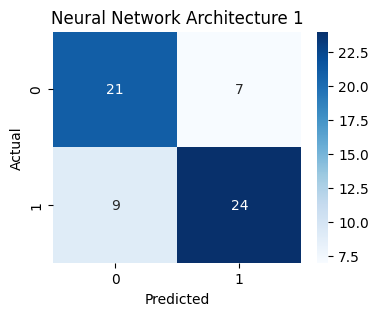

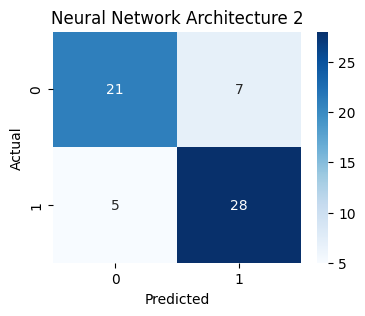

In [20]:
for result, predictions in [
    (nn_result_1, nn_pred_1),
    (nn_result_2, nn_pred_2)
]:
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(result["Model"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## Neural Network Architecture Comparison

| Model | Architecture Change | Final Accuracy | Final Precision | Final Recall | Final F1-score | Final ROC-AUC | Cross-validation F1 Mean |
|---|---|---:|---:|---:|---:|---:|---:|
| Neural Network Architecture 1 | Smaller baseline: `16 -> 8 -> output`, no dropout | 0.7377 | 0.7742 | 0.7273 | 0.7500 | 0.8193 | 0.8472 |
| Neural Network Architecture 2 | Larger model: `32 -> Dropout(0.3) -> 16 -> 8 -> output` | 0.8033 | 0.8000 | 0.8485 | 0.8235 | 0.8582 | 0.8678 |

Architecture 2 increased model capacity by adding more neurons and one extra hidden layer, then added dropout to reduce overfitting risk. In this run, the deeper/wider architecture improved held-out accuracy, precision, recall, F1-score and ROC-AUC compared with the smaller baseline. Its cross-validation F1 mean was also higher (`0.8678` vs `0.8472`), suggesting that the additional capacity helped the network learn useful non-linear relationships without hurting generalization in this experiment.

The selected Architecture 2 candidate performed better than the selected Architecture 1 candidate on the held-out split. This suggests the wider/deeper search space added useful capacity for this dataset, while dropout helped control overfitting enough to preserve validation and test performance.

# Final Model Comparison

The performance of all classifiers was compared using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The first table below is the hyperparameter tuning summary for the main classifiers: Logistic Regression, Decision Tree, KNN, Random Forest, and the Neural Network architectures. It shows what was tested, which settings were selected, the best validation result, and the final test-set metrics. The second table compares all final model variants, including feature-selection variants.

In [21]:
nn_results_df = pd.DataFrame([nn_result_1, nn_result_2])

main_tuning_summary_df = pd.concat(
    [classical_tuning_summary_df, neural_network_tuning_summary_df],
    ignore_index=True
)

display(main_tuning_summary_df)


final_results_df = pd.concat(
    [results_df, feature_selection_df, nn_results_df],
    ignore_index=True
)

comparison_columns = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
display(final_results_df[comparison_columns].sort_values(by="F1-score", ascending=False))


,Model,Parameters Tested,Best Parameters,Best Validation Result,Accuracy,Precision,Recall,F1-score,ROC-AUC,Confusion Matrix
0,Logistic Regression,"C: [0.01, 0.1, 1, 10]; solver: ['liblinear', '...","{'C': 1, 'solver': 'liblinear'}",5-fold CV F1 = 0.860,0.803279,0.800000,0.848485,0.823529,0.871212,"[[21, 7], [5, 28]]"
1,Decision Tree,"max_depth: [3, 5, 10, None]; criterion: ['gini...","{'criterion': 'entropy', 'max_depth': 3}",5-fold CV F1 = 0.837,0.770492,0.743590,0.878788,0.805556,0.830628,"[[18, 10], [4, 29]]"
2,KNN,"n_neighbors: [3, 5, 7, 9]; weights: ['uniform'...","{'n_neighbors': 7, 'weights': 'distance'}",5-fold CV F1 = 0.861,0.786885,0.777778,0.848485,0.811594,0.856061,"[[20, 8], [5, 28]]"
3,Random Forest,"n_estimators: [50, 100, 200]; max_depth: [3, 5...","{'criterion': 'entropy', 'max_depth': 3, 'n_es...",5-fold CV F1 = 0.877,0.754098,0.750000,0.818182,0.782609,0.876623,"[[19, 9], [6, 27]]"
4,Neural Network Architecture 1,"hidden_layers: [(16, 8), (24, 12)]; dropout_ra...","{'batch_size': 16, 'dropout_rate': 0.0, 'epoch...",Validation accuracy = 0.878,0.737705,0.774194,0.727273,0.750000,0.819264,"[[21, 7], [9, 24]]"
5,Neural Network Architecture 2,"hidden_layers: [(32, 16, 8), (64, 32, 16)]; dr...","{'batch_size': 16, 'dropout_rate': 0.3, 'epoch...",Validation accuracy = 0.918,0.803279,0.800000,0.848485,0.823529,0.858225,"[[21, 7], [5, 28]]"


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529,0.871212
9,Neural Network Architecture 2,0.803279,0.800000,0.848485,0.823529,0.858225
6,KNN with Feature Selection,0.803279,0.800000,0.848485,0.823529,0.862554
4,Logistic Regression with Feature Selection,0.803279,0.818182,0.818182,0.818182,0.882035
7,Random Forest with Feature Selection,0.786885,0.777778,0.848485,0.811594,0.859307
2,KNN,0.786885,0.777778,0.848485,0.811594,0.856061
1,Decision Tree,0.770492,0.743590,0.878788,0.805556,0.830628
3,Random Forest,0.754098,0.750000,0.818182,0.782609,0.876623
5,Decision Tree with Feature Selection,0.754098,0.764706,0.787879,0.776119,0.783009
8,Neural Network Architecture 1,0.737705,0.774194,0.727273,0.750000,0.819264


## Classifier Evaluation Discussion

The best-performing model was identified mainly by F1-score because this metric balances precision and recall. This is important for heart disease prediction, where a false negative may miss a patient who is actually at risk and a false positive may create unnecessary concern or follow-up.

### Logistic Regression

- Strengths: Logistic Regression produced one of the strongest final results, with F1-score `0.8286` and the highest ROC-AUC among the all-feature models (`0.8810`). It is fast, stable and easy to explain because coefficients show how each feature pushes risk upward or downward.
- Weaknesses: It assumes a mostly linear relationship between the scaled input features and the log-odds of heart disease, so it may miss complex non-linear interactions.
- Training behavior: The model trained quickly and benefited from scaling. Cross-validation F1 mean was `0.8539`, showing good average stability across folds.
- Overfitting or underfitting: There is little evidence of severe overfitting because regularization was selected by GridSearchCV and cross-validation remained strong. If it underfits, it is mainly because a linear decision boundary cannot capture every clinical interaction.
- Difference from other models: It outperformed the Decision Tree because it generalized better, and it matched KNN while providing better interpretability and ROC-AUC.

### Logistic Regression with Feature Selection

- Strengths: This was the best final train-test model by F1-score (`0.8358`) and accuracy (`0.8197`). It also keeps the model simpler by using selected features, which improves interpretability for HealthGuard.
- Weaknesses: Feature selection can remove information that might help some models, and the selected subset should be revalidated if the dataset changes.
- Training behavior: The selected model used `C=0.1` and `lbfgs`, giving slightly stronger precision than the full-feature Logistic Regression while keeping recall high.
- Overfitting or underfitting: The cross-validation F1 mean was `0.8644` with moderate variation, suggesting good generalization without suspiciously perfect scores.
- Difference from other models: It improved the precision-recall balance compared with full Logistic Regression, likely because noisy or less useful features were removed.

### Decision Tree

- Strengths: The Decision Tree is easy to interpret because predictions are based on visible split rules. It also achieved high recall (`0.8788`), meaning it found many positive cases.
- Weaknesses: Its precision (`0.7436`) and F1-score (`0.8056`) were lower than Logistic Regression, KNN and Random Forest, showing more false positives.
- Training behavior: GridSearchCV selected a shallow tree (`max_depth=3`), which restricts complexity and helps prevent memorization.
- Overfitting or underfitting: A deeper tree could overfit this small cleaned dataset. The selected shallow tree may slightly underfit because it cannot model many detailed patterns, but that trade-off improves generalization.
- Difference from other models: It performs worse than Random Forest because a single tree is more sensitive to individual split decisions, while an ensemble averages many trees.

### Decision Tree with Feature Selection

- Strengths: It remains interpretable and uses fewer input features.
- Weaknesses: It had the weakest final F1-score (`0.7761`) and lower recall (`0.7879`) than the full Decision Tree, so the selected features did not help this model.
- Training behavior: The same shallow-depth setting was selected, but the reduced feature space limited useful split options.
- Overfitting or underfitting: This result suggests underfitting. With fewer features and a shallow tree, the model did not have enough useful split structure to match stronger models.
- Difference from other models: Feature selection helped Logistic Regression but hurt the Decision Tree, showing that preprocessing choices affect model families differently.

### KNN

- Strengths: KNN matched full Logistic Regression on final F1-score (`0.8286`) and recall (`0.8788`). It can capture non-linear local patterns because it predicts from neighboring patients.
- Weaknesses: It is less interpretable than Logistic Regression and depends heavily on scaling and distance behavior. It can also become slower with larger datasets because prediction requires neighbor lookup.
- Training behavior: KNN has minimal training cost because it stores the training data. GridSearchCV selected `n_neighbors=9` and `uniform` weights, which smooths predictions instead of relying too much on one close neighbor.
- Overfitting or underfitting: The selected neighbor count reduces overfitting compared with very small `k`. Cross-validation F1 mean (`0.8270`) was lower than the top feature-selected models, so its local-distance strategy was useful but not the most stable.
- Difference from other models: It performed close to Logistic Regression, but without the same explainability or platform simplicity.

### KNN with Feature Selection

- Strengths: It kept the same final F1-score as Random Forest (`0.8235`) and had the strongest cross-validation F1 mean (`0.8716`) with the lowest F1 standard deviation among the compared models.
- Weaknesses: The final held-out test F1-score did not beat Logistic Regression with Feature Selection. It also remains harder to explain to users than a coefficient-based model.
- Training behavior: Feature selection likely improved distance quality by removing less helpful dimensions, which is important for KNN.
- Overfitting or underfitting: Cross-validation suggests stable behavior, but the single final test split was slightly weaker than the best model. This does not indicate severe overfitting, but it shows the need to consider both CV and final test metrics.
- Difference from other models: It is competitive because KNN benefits from cleaner feature space, but it is less convenient for HealthGuard deployment and explanation.

### Random Forest

- Strengths: Random Forest achieved balanced final metrics with precision `0.8000`, recall `0.8485`, F1-score `0.8235` and ROC-AUC `0.8755`. It can model non-linear feature interactions better than Logistic Regression.
- Weaknesses: It is less transparent than Logistic Regression and did not outperform the simpler selected Logistic Regression model.
- Training behavior: GridSearchCV selected `n_estimators=200`, `criterion=entropy` and `max_depth=3`. The shallow depth controls tree complexity while the ensemble reduces variance.
- Overfitting or underfitting: The shallow depth reduces overfitting risk, but may also limit how much non-linear structure the forest can capture. Cross-validation F1 mean (`0.8502`) was strong but not the highest.
- Difference from other models: It improves over a single Decision Tree because averaging many trees stabilizes predictions, but the dataset is small enough that the extra model complexity does not clearly beat Logistic Regression.

### Random Forest with Feature Selection

- Strengths: It had strong cross-validation performance (`0.8661` mean F1), showing that feature-selected Random Forest models can be stable across folds.
- Weaknesses: Its final test F1-score (`0.8116`) was lower than the full Random Forest and the selected Logistic Regression model.
- Training behavior: With only 50 trees selected by tuning, the model trained efficiently, but the reduced feature set may have removed variables useful for tree splits.
- Overfitting or underfitting: There is no perfect-score behavior, but the lower final test score suggests the feature-selected forest may underfit or lose helpful split diversity.
- Difference from other models: Random Forest can use weak signals across many variables; reducing those variables may hurt it more than it hurts Logistic Regression.

### Neural Network Architecture 1

- Strengths: Architecture 1 was compact and selected `hidden_layers=(16, 8)`, `dropout_rate=0.0`, `learning_rate=0.001`, `epochs=50`, and `batch_size=16`. It can model non-linear relationships without manual rule design.
- Weaknesses: It did not outperform the best classical models, likely because the cleaned dataset is small for neural-network training.
- Training behavior: The selected two-layer network reached held-out accuracy `0.7377`, precision `0.7742`, recall `0.7273`, F1-score `0.7500`, and ROC-AUC `0.8193`.
- Overfitting or underfitting: Its cross-validation F1 mean was `0.8472`, but its held-out F1-score was lower than Architecture 2, suggesting the simpler model had less useful capacity in this run.
- Difference from other models: Neural networks often need more data to outperform classical models. Here, simpler models were more reliable and easier to explain.

### Neural Network Architecture 2

- Strengths: Architecture 2 selected `hidden_layers=(32, 16, 8)`, `dropout_rate=0.3`, `learning_rate=0.001`, `epochs=50`, and `batch_size=16`. It improved held-out accuracy, recall, F1-score and ROC-AUC over Architecture 1.
- Weaknesses: It still did not clearly dominate the strongest classical models, so the added complexity should be justified by validation stability and deployment needs.
- Training behavior: The selected dropout network reached held-out accuracy `0.8033`, precision `0.8000`, recall `0.8485`, F1-score `0.8235`, and ROC-AUC `0.8582`.
- Overfitting or underfitting: The cross-validation F1 mean was `0.8678`, higher than Architecture 1, which suggests the added capacity generalized better in this experiment.
- Difference from other models: It was competitive with the strongest classical models, but Logistic Regression and KNN remain easier to explain and cheaper to train.

## Final Recommendation for HealthGuard

The recommended model for HealthGuard is **Logistic Regression with Feature Selection**. It achieved the best final F1-score (`0.8358`), the best final accuracy (`0.8197`), strong ROC-AUC (`0.8799`) and a good precision-recall balance. It is also fast, easy to deploy, and easier to explain than KNN, Random Forest or Neural Networks. This matters for a health monitoring platform because users and reviewers need understandable risk factors, not only a prediction score. The saved Logistic Regression model and scaler can support the current FastAPI integration, while the selected-feature analysis provides a defensible explanation of why the model is suitable for HealthGuard.

## K-Fold Cross Validation

A single train-test split can be sensitive to which records happen to be assigned to the test set. To evaluate model stability, 5-fold `StratifiedKFold` cross validation was applied to each classification model. Stratification preserves the class balance in each fold, which is important for heart disease prediction because both positive and negative classes must be represented consistently.

Accuracy, precision, recall and F1-score are reported as mean and standard deviation across folds. A higher mean indicates stronger average performance, while a lower standard deviation indicates more stable behavior across different validation splits.

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scoring = {
    "Accuracy": "accuracy",
    "Precision": make_scorer(precision_score, zero_division=0),
    "Recall": make_scorer(recall_score, zero_division=0),
    "F1 Score": make_scorer(f1_score, zero_division=0)
}

cross_validation_results = []


def add_cv_summary(model_name, metric_scores):
    summary = {"Model": model_name}

    for metric_name, scores in metric_scores.items():
        summary[f"{metric_name} Mean"] = np.mean(scores)
        summary[f"{metric_name} Std"] = np.std(scores)

    cross_validation_results.append(summary)


for model_name, model in best_models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", clone(model))
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=-1
    )

    add_cv_summary(
        model_name,
        {metric: scores[f"test_{metric}"] for metric in cv_scoring}
    )


for model_name, model in best_feature_selection_models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("feature_selection", SelectKBest(score_func=f_classif, k=8)),
        ("model", clone(model))
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=-1
    )

    add_cv_summary(
        model_name + " with Feature Selection",
        {metric: scores[f"test_{metric}"] for metric in cv_scoring}
    )


def build_neural_network_1(input_dim):
    tf.keras.utils.set_random_seed(SEED)
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_neural_network_2(input_dim):
    tf.keras.utils.set_random_seed(SEED)
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation="relu"),
        Dropout(0.3, seed=SEED),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


def evaluate_neural_network_cv(model_name, build_model):
    metric_scores = {
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1 Score": []
    }

    for fold, (train_index, test_index) in enumerate(cv.split(X, y), start=1):
        X_train_fold = X.iloc[train_index]
        X_test_fold = X.iloc[test_index]
        y_train_fold = y.iloc[train_index]
        y_test_fold = y.iloc[test_index]

        fold_scaler = StandardScaler()
        X_train_fold_scaled = fold_scaler.fit_transform(X_train_fold)
        X_test_fold_scaled = fold_scaler.transform(X_test_fold)

        nn_model = build_model(X_train_fold_scaled.shape[1])
        nn_model.fit(
            X_train_fold_scaled,
            y_train_fold,
            epochs=50,
            batch_size=16,
            verbose=0
        )

        y_pred_fold = (nn_model.predict(X_test_fold_scaled, verbose=0).ravel() > 0.5).astype("int32")

        metric_scores["Accuracy"].append(accuracy_score(y_test_fold, y_pred_fold))
        metric_scores["Precision"].append(precision_score(y_test_fold, y_pred_fold, zero_division=0))
        metric_scores["Recall"].append(recall_score(y_test_fold, y_pred_fold, zero_division=0))
        metric_scores["F1 Score"].append(f1_score(y_test_fold, y_pred_fold, zero_division=0))

    add_cv_summary(model_name, metric_scores)


evaluate_neural_network_cv("Neural Network Architecture 1", build_neural_network_1)
evaluate_neural_network_cv("Neural Network Architecture 2", build_neural_network_2)

cross_validation_df = pd.DataFrame(cross_validation_results)
cross_validation_df = cross_validation_df.sort_values(
    by="F1 Score Mean",
    ascending=False
).reset_index(drop=True)

cross_validation_df.to_csv(RESULTS_DIR / "cross_validation_results.csv", index=False)
display(cross_validation_df)


,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Score Mean,F1 Score Std
0,KNN with Feature Selection,0.854262,0.022329,0.842197,0.050506,0.908712,0.050485,0.871568,0.016166
1,Neural Network Architecture 2,0.854208,0.024989,0.858964,0.058006,0.883902,0.062390,0.867798,0.023235
2,Random Forest with Feature Selection,0.841148,0.030368,0.821142,0.049763,0.914394,0.080303,0.861215,0.028357
3,Logistic Regression with Feature Selection,0.841148,0.049777,0.831753,0.059746,0.896402,0.078005,0.859283,0.043648
4,Random Forest,0.834536,0.045493,0.826551,0.043948,0.884091,0.080017,0.851786,0.043796
5,KNN,0.827978,0.037566,0.807472,0.024003,0.896212,0.062636,0.848824,0.037657
6,Neural Network Architecture 1,0.831093,0.024606,0.834244,0.043541,0.865909,0.059246,0.847218,0.024125
7,Logistic Regression,0.831202,0.028084,0.837956,0.050835,0.865530,0.099427,0.845397,0.035606
8,Decision Tree,0.761421,0.061548,0.744945,0.055797,0.866288,0.090811,0.797319,0.048257
9,Decision Tree with Feature Selection,0.768197,0.038005,0.773081,0.043650,0.816667,0.084686,0.791019,0.041979


Cross-validation helps identify whether a model performs consistently or depends heavily on one favorable split. Models with similar mean scores can be compared using their standard deviations: lower variation suggests more reliable performance across patient subsets.

For this project, F1-score stability is especially useful because it balances precision and recall. A stable F1-score means the model is more consistently balancing false positives and false negatives, which matters in a heart disease risk screening context.

## Learning Curve Analysis

Learning curves show how model performance changes as the amount of training data increases. Each plot compares the training score with the validation score across different training-set sizes using 5-fold stratified cross validation.

The analysis uses F1-score because it balances precision and recall, which is important for heart disease prediction. A large gap between training and validation scores suggests overfitting. Low training and validation scores suggest underfitting. Similar high scores suggest better generalization.

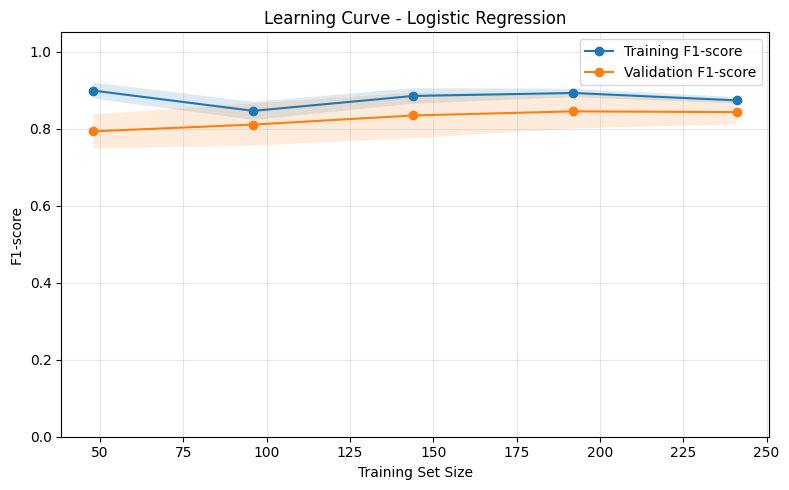

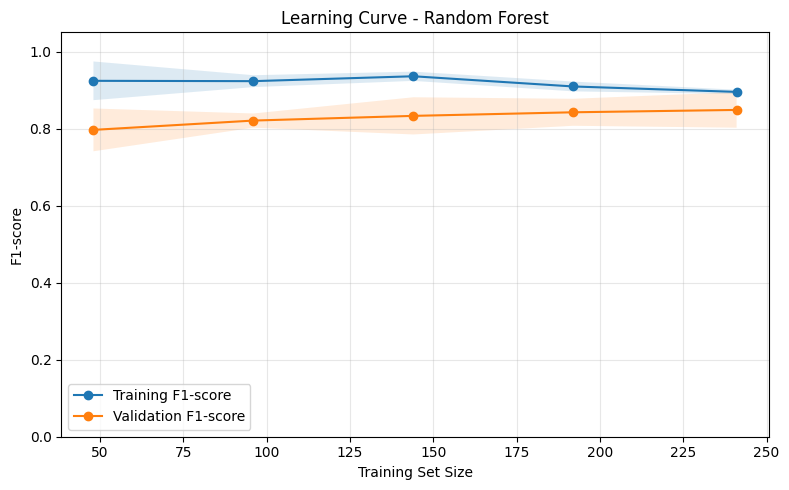

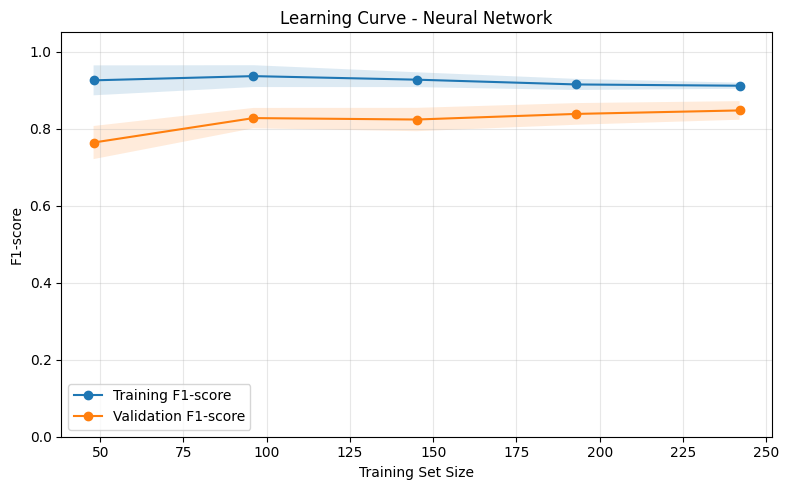

,Model,Training Size,Training F1 Mean,Training F1 Std,Validation F1 Mean,Validation F1 Std
0,Logistic Regression,48,0.898682,0.020796,0.792977,0.044277
1,Logistic Regression,96,0.846123,0.023510,0.810520,0.055006
2,Logistic Regression,144,0.884855,0.020088,0.834173,0.058791
3,Logistic Regression,192,0.892553,0.010968,0.844814,0.044698
4,Logistic Regression,241,0.873401,0.008436,0.842830,0.031957
5,Random Forest,48,0.924095,0.050248,0.796712,0.055544
6,Random Forest,96,0.923247,0.015418,0.820894,0.018408
7,Random Forest,144,0.935936,0.012024,0.833096,0.048296
8,Random Forest,192,0.909431,0.012708,0.842415,0.035033
9,Random Forest,241,0.895373,0.005589,0.848521,0.046168


In [23]:
learning_curve_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
learning_curve_train_sizes = np.linspace(0.2, 1.0, 5)


def plot_sklearn_learning_curve(model_name, estimator, output_filename):
    train_sizes_abs, train_scores, validation_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        train_sizes=learning_curve_train_sizes,
        cv=learning_curve_cv,
        scoring=make_scorer(f1_score, zero_division=0),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes_abs, train_mean, marker="o", label="Training F1-score")
    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15)
    plt.plot(train_sizes_abs, validation_mean, marker="o", label="Validation F1-score")
    plt.fill_between(
        train_sizes_abs,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.15
    )
    plt.xlabel("Training Set Size")
    plt.ylabel("F1-score")
    plt.title(f"Learning Curve - {model_name}")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / output_filename, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame({
        "Model": model_name,
        "Training Size": train_sizes_abs,
        "Training F1 Mean": train_mean,
        "Training F1 Std": train_std,
        "Validation F1 Mean": validation_mean,
        "Validation F1 Std": validation_std
    })


logistic_learning_curve_df = plot_sklearn_learning_curve(
    "Logistic Regression",
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", clone(best_models["Logistic Regression"]))
    ]),
    "logistic_learning_curve.png"
)

randomforest_learning_curve_df = plot_sklearn_learning_curve(
    "Random Forest",
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", clone(best_models["Random Forest"]))
    ]),
    "randomforest_learning_curve.png"
)


def build_learning_curve_neural_network(input_dim):
    tf.keras.utils.set_random_seed(SEED)
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


def neural_network_learning_curve():
    train_sizes_abs = []
    train_score_rows = []
    validation_score_rows = []

    for train_fraction in learning_curve_train_sizes:
        fold_train_scores = []
        fold_validation_scores = []
        current_train_size = None

        for train_index, validation_index in learning_curve_cv.split(X, y):
            train_pool_X = X.iloc[train_index]
            train_pool_y = y.iloc[train_index]
            validation_X = X.iloc[validation_index]
            validation_y = y.iloc[validation_index]

            if train_fraction < 1.0:
                subset_X, _, subset_y, _ = train_test_split(
                    train_pool_X,
                    train_pool_y,
                    train_size=train_fraction,
                    random_state=SEED,
                    stratify=train_pool_y
                )
            else:
                subset_X = train_pool_X
                subset_y = train_pool_y

            current_train_size = len(subset_X)

            fold_scaler = StandardScaler()
            subset_X_scaled = fold_scaler.fit_transform(subset_X)
            validation_X_scaled = fold_scaler.transform(validation_X)

            nn_model = build_learning_curve_neural_network(subset_X_scaled.shape[1])
            nn_model.fit(
                subset_X_scaled,
                subset_y,
                epochs=50,
                batch_size=16,
                verbose=0
            )

            train_predictions = (nn_model.predict(subset_X_scaled, verbose=0).ravel() > 0.5).astype("int32")
            validation_predictions = (nn_model.predict(validation_X_scaled, verbose=0).ravel() > 0.5).astype("int32")

            fold_train_scores.append(f1_score(subset_y, train_predictions, zero_division=0))
            fold_validation_scores.append(f1_score(validation_y, validation_predictions, zero_division=0))

        train_sizes_abs.append(current_train_size)
        train_score_rows.append(fold_train_scores)
        validation_score_rows.append(fold_validation_scores)

    train_scores = np.array(train_score_rows)
    validation_scores = np.array(validation_score_rows)
    train_sizes_abs = np.array(train_sizes_abs)

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes_abs, train_mean, marker="o", label="Training F1-score")
    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15)
    plt.plot(train_sizes_abs, validation_mean, marker="o", label="Validation F1-score")
    plt.fill_between(
        train_sizes_abs,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.15
    )
    plt.xlabel("Training Set Size")
    plt.ylabel("F1-score")
    plt.title("Learning Curve - Neural Network")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "neuralnetwork_learning_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame({
        "Model": "Neural Network",
        "Training Size": train_sizes_abs,
        "Training F1 Mean": train_mean,
        "Training F1 Std": train_std,
        "Validation F1 Mean": validation_mean,
        "Validation F1 Std": validation_std
    })


neuralnetwork_learning_curve_df = neural_network_learning_curve()

learning_curve_summary_df = pd.concat(
    [logistic_learning_curve_df, randomforest_learning_curve_df, neuralnetwork_learning_curve_df],
    ignore_index=True
)

display(learning_curve_summary_df)


The Logistic Regression learning curve is useful for checking whether the linear model has enough capacity. If training and validation scores are close but both plateau below the strongest models, the model is likely underfitting because the decision boundary is too simple.

The Random Forest learning curve helps identify overfitting. A high training score with a lower validation score indicates that the ensemble is fitting training patterns more strongly than it generalizes. If the validation curve improves as training size increases, more data or stronger regularization may reduce the gap.

The Neural Network learning curve shows whether the network benefits from additional data and whether its training score separates from validation score. A widening gap suggests overfitting, while low and similar scores suggest underfitting or insufficient training capacity. Stable convergence between the two curves indicates healthier generalization behavior.

## ROC-AUC Evaluation

ROC curves compare each classifier across all probability thresholds by plotting the true positive rate against the false positive rate. The ROC-AUC score summarizes this curve into a single value: higher scores indicate better separation between patients with and without heart disease.

The comparison below includes the classical models, the same models after feature selection, and both neural network architectures.

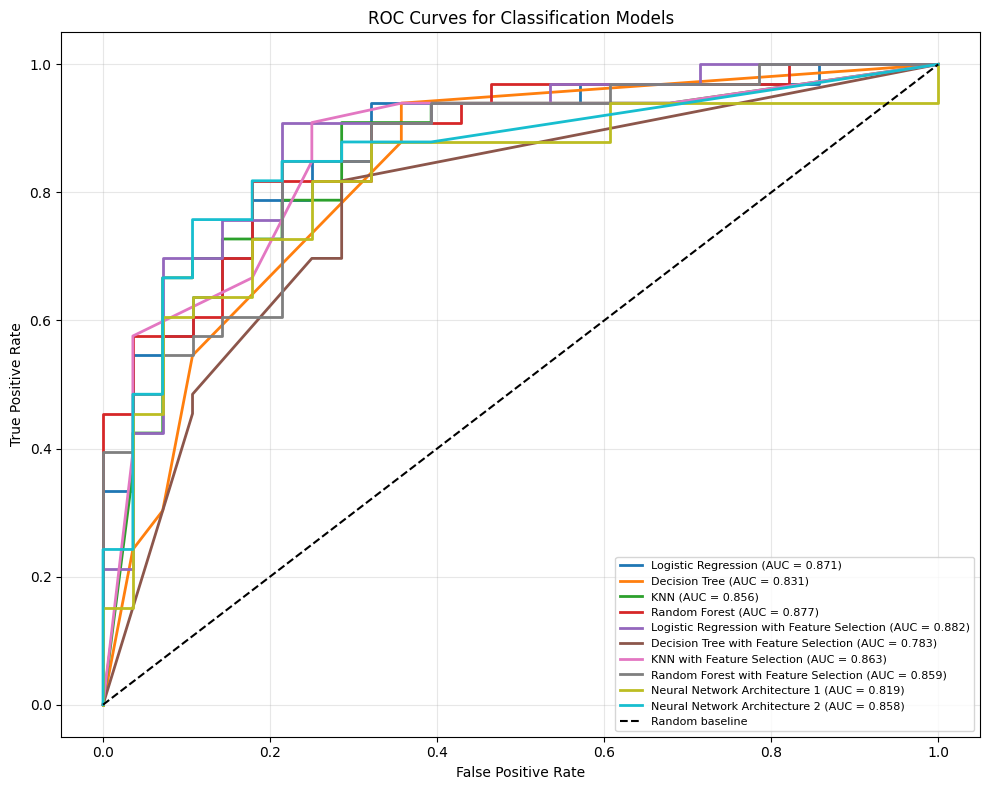

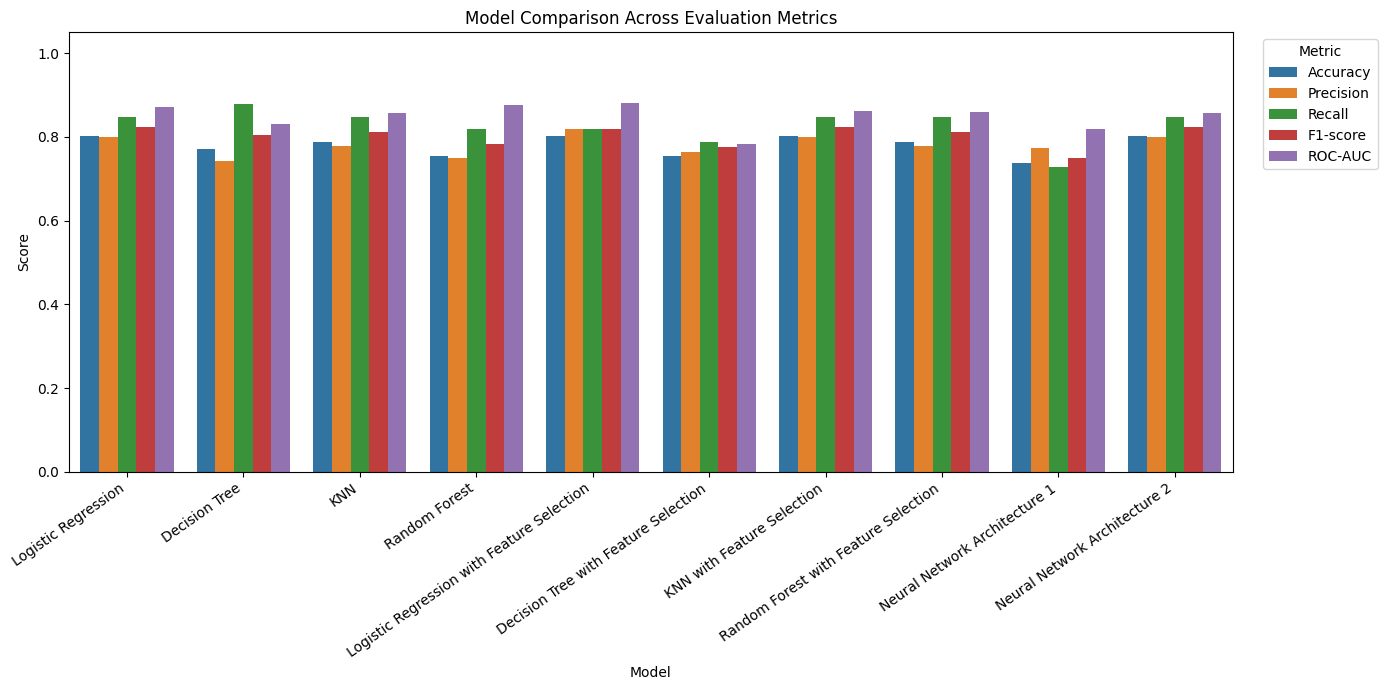

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
4,Logistic Regression with Feature Selection,0.803279,0.818182,0.818182,0.818182,0.882035
3,Random Forest,0.754098,0.750000,0.818182,0.782609,0.876623
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529,0.871212
6,KNN with Feature Selection,0.803279,0.800000,0.848485,0.823529,0.862554
7,Random Forest with Feature Selection,0.786885,0.777778,0.848485,0.811594,0.859307
9,Neural Network Architecture 2,0.803279,0.800000,0.848485,0.823529,0.858225
2,KNN,0.786885,0.777778,0.848485,0.811594,0.856061
1,Decision Tree,0.770492,0.743590,0.878788,0.805556,0.830628
8,Neural Network Architecture 1,0.737705,0.774194,0.727273,0.750000,0.819264
5,Decision Tree with Feature Selection,0.754098,0.764706,0.787879,0.776119,0.783009


In [24]:
roc_score_sets = {
    **model_roc_scores,
    **feature_selection_roc_scores,
    "Neural Network Architecture 1": nn_score_1,
    "Neural Network Architecture 2": nn_score_2
}

plt.figure(figsize=(10, 8))

for model_name, y_score in roc_score_sets.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classification Models")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
model_comparison_plot_df = final_results_df[["Model"] + metrics_to_plot].melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=model_comparison_plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)
plt.ylim(0, 1.05)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Comparison Across Evaluation Metrics")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

display(final_results_df[["Model"] + metrics_to_plot].sort_values(by="ROC-AUC", ascending=False))


The ROC comparison complements accuracy, precision, recall and F1-score by evaluating ranking quality across thresholds instead of only the default classification cutoff. Models with higher ROC-AUC values are better at assigning higher risk scores to patients who truly have heart disease.

The grouped model comparison chart makes it easier to identify trade-offs. A model may have strong recall but lower precision, or strong F1-score but weaker ROC-AUC, so the final model choice should consider the clinical goal and the cost of false negatives versus false positives.

# Clustering Analysis

Clustering is used here as an unsupervised exploration step. The goal is not to train another classifier, but to check whether patients naturally form groups based on their clinical measurements.

Before clustering, the target/class label (`target`) is removed. K-Means only receives the feature matrix (`X_train_scaled`), so the algorithm does not know whether each patient has heart disease. The true labels (`y_train`) are used only after clustering for evaluation and interpretation.

K-Means clustering is evaluated for `k` values from 2 to 10. For each cluster count, the notebook calculates:

- inertia for the Elbow Method
- Silhouette Score for internal cluster separation quality
- Adjusted Rand Index (ARI) against the true labels
- Normalized Mutual Information (NMI) against the true labels

All clustering plots are saved under `ml/results/plots`.

C:\Users\olsas\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\olsas\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,Inertia,Silhouette Score,Adjusted Rand Index,Normalized Mutual Information
0,2,2652.900983,0.168272,0.411014,0.350196
1,3,2438.279186,0.117103,0.255753,0.259532
2,4,2266.057235,0.120918,0.182632,0.190186
3,5,2153.978253,0.118705,0.162573,0.188181
4,6,2065.459691,0.111974,0.129904,0.187912
5,7,2000.612877,0.126136,0.149989,0.194327
6,8,1935.836780,0.110018,0.111842,0.190519
7,9,1877.021409,0.104078,0.120601,0.202133
8,10,1811.716344,0.099790,0.118776,0.211413


Best cluster count based on Silhouette Score: 2
Best Silhouette Score: 0.16827226824363017
Adjusted Rand Index for best k: 0.41101374337816227
Normalized Mutual Information for best k: 0.3501962018766964


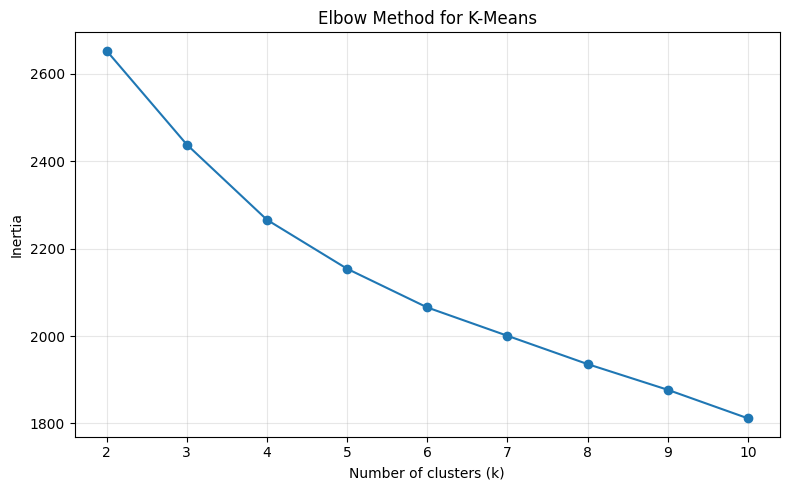

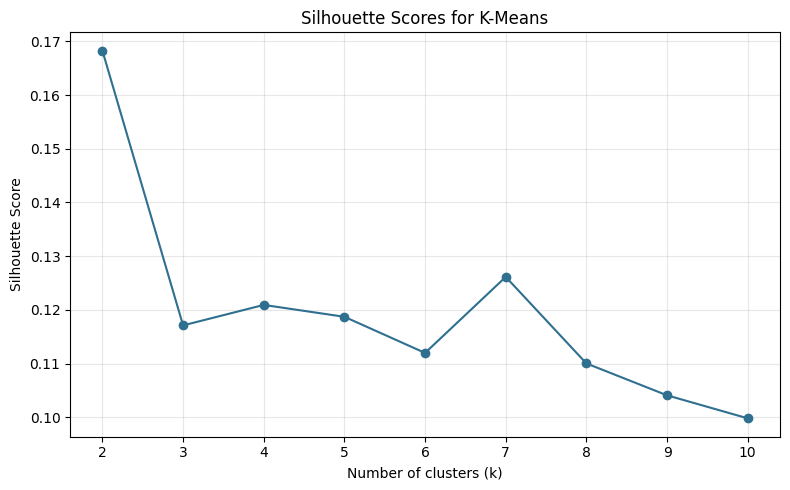

In [25]:
clustering_features = X_train_scaled
clustering_true_labels = y_train

clustering_results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    clusters = kmeans.fit_predict(clustering_features)

    clustering_results.append({
        "k": k,
        "Inertia": kmeans.inertia_,
        "Silhouette Score": silhouette_score(clustering_features, clusters),
        "Adjusted Rand Index": adjusted_rand_score(clustering_true_labels, clusters),
        "Normalized Mutual Information": normalized_mutual_info_score(clustering_true_labels, clusters)
    })

clustering_evaluation_df = pd.DataFrame(clustering_results)

best_cluster_row = clustering_evaluation_df.loc[
    clustering_evaluation_df["Silhouette Score"].idxmax()
]
best_k = int(best_cluster_row["k"])

clustering_evaluation_df.to_csv(RESULTS_DIR / "clustering_evaluation.csv", index=False)

display(clustering_evaluation_df)
print("Best cluster count based on Silhouette Score:", best_k)
print("Best Silhouette Score:", best_cluster_row["Silhouette Score"])
print("Adjusted Rand Index for best k:", best_cluster_row["Adjusted Rand Index"])
print("Normalized Mutual Information for best k:", best_cluster_row["Normalized Mutual Information"])

plt.figure(figsize=(8, 5))
plt.plot(clustering_evaluation_df["k"], clustering_evaluation_df["Inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(clustering_evaluation_df["k"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    clustering_evaluation_df["k"],
    clustering_evaluation_df["Silhouette Score"],
    marker="o",
    color="#2f6f8f"
)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means")
plt.xticks(clustering_evaluation_df["k"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "silhouette_scores.png", dpi=300, bbox_inches="tight")
plt.show()


## K-Means Clustering with Automatically Selected k

The best cluster count is selected using the highest Silhouette Score. This prioritizes compact, well-separated clusters without using the target labels during cluster selection. ARI and NMI are reported afterward to compare the discovered groups with the known diagnosis labels.

In [26]:
best_kmeans = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
clusters = best_kmeans.fit_predict(clustering_features)

ari_score = adjusted_rand_score(clustering_true_labels, clusters)
nmi_score = normalized_mutual_info_score(clustering_true_labels, clusters)

print("Selected k:", best_k)
print("Adjusted Rand Index:", ari_score)
print("Normalized Mutual Information:", nmi_score)


Selected k: 2
Adjusted Rand Index: 0.41101374337816227
Normalized Mutual Information: 0.3501962018766964


## PCA Visualization of Selected Clusters

PCA is used only for visualization. It reduces the scaled feature matrix to two components so the selected K-Means clusters can be plotted in 2D. A second PCA plot colors the same patients by their true labels, which makes it easier to compare the unsupervised clusters with the actual heart disease classes.


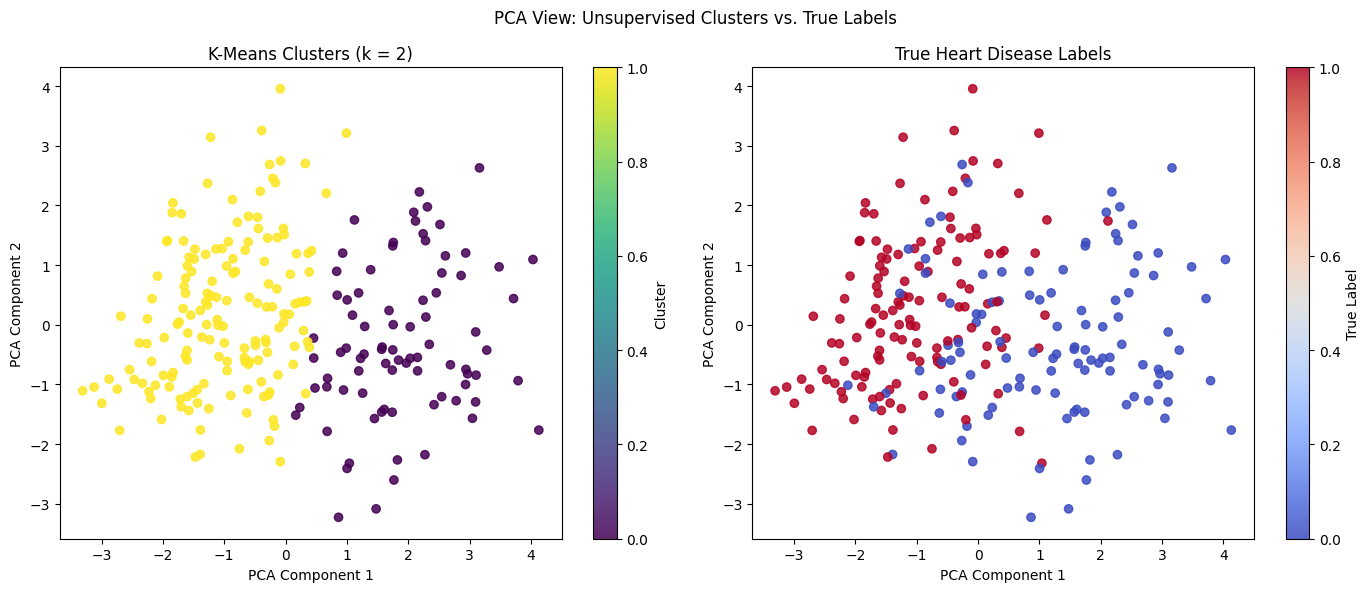

,PCA Component 1,PCA Component 2,Cluster,True Label
0,0.991250,3.210195,1,1
1,1.566804,-1.463911,0,0
2,2.934348,-1.002597,0,0
3,1.747149,1.321066,0,0
4,-1.443213,-1.088738,1,1


In [27]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(clustering_features)
pca_cluster_df = pd.DataFrame({
    "PCA Component 1": X_pca[:, 0],
    "PCA Component 2": X_pca[:, 1],
    "Cluster": clusters,
    "True Label": clustering_true_labels.values
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cluster_plot = axes[0].scatter(
    pca_cluster_df["PCA Component 1"],
    pca_cluster_df["PCA Component 2"],
    c=pca_cluster_df["Cluster"],
    cmap="viridis",
    alpha=0.85
)
axes[0].set_title(f"K-Means Clusters (k = {best_k})")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
fig.colorbar(cluster_plot, ax=axes[0], label="Cluster")

label_plot = axes[1].scatter(
    pca_cluster_df["PCA Component 1"],
    pca_cluster_df["PCA Component 2"],
    c=pca_cluster_df["True Label"],
    cmap="coolwarm",
    alpha=0.85
)
axes[1].set_title("True Heart Disease Labels")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")
fig.colorbar(label_plot, ax=axes[1], label="True Label")

plt.suptitle("PCA View: Unsupervised Clusters vs. True Labels")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "kmeans_pca_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

display(pca_cluster_df.head())


The clustering results are compared with the true class labels using Adjusted Rand Index and Normalized Mutual Information. ARI measures how closely the cluster assignments match the actual labels after correcting for chance, while NMI measures the amount of shared information between the discovered clusters and the true classes.

These metrics are not used to train or choose the clusters. They are included only as an interpretation step after K-Means has already grouped patients using the feature values.

## Clustering Findings

The Elbow Method and Silhouette Score plots provide complementary views of cluster quality. The elbow curve shows how inertia decreases as more clusters are added, while the Silhouette Score identifies the cluster count with the strongest separation. The automatically selected `best_k` is based on the highest Silhouette Score.

For this dataset, the best silhouette result selects a small number of broad patient groups rather than many detailed subgroups. The ARI and NMI values show partial overlap with the true heart disease labels, which means the clusters capture some diagnosis-related structure but do not perfectly reproduce the target classes. This is expected because K-Means groups patients by overall feature similarity, not by the known class label.

In practical terms, the clusters can be interpreted as exploratory patient profiles. A cluster may contain patients with similar combinations of chest pain type, exercise response, ST depression, maximum heart rate, major vessel count, and thalassemia values. The clusters are useful for understanding structure in the data, but they should not be treated as a replacement for the supervised classifiers or as medical diagnoses.

## Save Results and Best Classical Model

In [28]:
final_results_df.to_csv(RESULTS_DIR / "final_model_results.csv", index=False)
final_results_df.to_csv(ML_DIR / "model_comparison_results.csv", index=False)

best_classical_model_name = results_df.sort_values(by="F1-score", ascending=False).iloc[0]["Model"]
best_classical_model = best_models[best_classical_model_name]
logistic_api_model = best_models["Logistic Regression"]

joblib.dump(best_classical_model, MODELS_DIR / "best_classical_model.pkl")
joblib.dump(logistic_api_model, MODELS_DIR / "logistic_model.pkl")
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")
joblib.dump(list(X.columns), MODELS_DIR / "columns.pkl")


def to_serializable(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, dict):
        return {key: to_serializable(item) for key, item in value.items()}
    if isinstance(value, list):
        return [to_serializable(item) for item in value]
    if pd.isna(value):
        return None
    return value


def selected_features_for_model(model_name):
    if "with Feature Selection" in model_name:
        return list(selected_features)
    return None


def architecture_for_model(model_name):
    if model_name == "Neural Network Architecture 1":
        return "16 neurons -> 8 neurons -> output"
    if model_name == "Neural Network Architecture 2":
        return "32 neurons + Dropout -> 16 neurons -> 8 neurons -> output"
    return None


def training_history_for_model(model_name):
    if model_name == "Neural Network Architecture 1":
        return nn_training_history_1
    if model_name == "Neural Network Architecture 2":
        return nn_training_history_2
    return None


classification_export_df = final_results_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

classification_export = []
for rank, row in classification_export_df.iterrows():
    model_name = row["Model"]
    classification_export.append({
        "rank": int(rank + 1),
        "modelName": model_name,
        "modelType": "Classification",
        "datasetName": "Heart Disease Dataset (heart.csv)",
        "accuracy": float(row["Accuracy"]),
        "precision": float(row["Precision"]),
        "recall": float(row["Recall"]),
        "f1Score": float(row["F1-score"]),
        "rocAuc": float(row["ROC-AUC"]),
        "confusionMatrix": to_serializable(row["Confusion Matrix"]),
        "bestHyperparameters": to_serializable(row.get("Best Parameters")),
        "selectedFeatures": selected_features_for_model(model_name),
        "architecture": architecture_for_model(model_name),
        "trainingHistory": training_history_for_model(model_name),
        "trainingDate": "2026-06-02",
        "status": "Evaluated"
    })

feature_importance_export = []
for _, row in feature_importance_df.head(10).iterrows():
    feature_importance_export.append({
        "feature": row["Feature"],
        "importance": float(row["Combined Importance"]),
        "healthIndicator": health_indicator_names.get(row["Feature"]),
        "direction": row["Logistic Regression Direction"],
        "interpretation": indicator_explanations.get(row["Feature"]),
        "logisticRegressionCoefficient": float(row["Logistic Regression Coefficient"]),
        "randomForestImportance": float(row["Random Forest Importance"])
    })

clustering_export = [{
    "rank": 1,
    "modelName": "K-Means Clustering",
    "modelType": "Clustering",
    "datasetName": "Heart Disease Dataset (heart.csv)",
    "algorithmName": "K-Means",
    "numberOfClusters": int(best_k),
    "silhouetteScore": float(best_cluster_row["Silhouette Score"]),
    "clusterClassMatchScore": float(best_cluster_row["Adjusted Rand Index"]),
    "labelComparison": {
        "adjustedRandIndex": float(best_cluster_row["Adjusted Rand Index"]),
        "normalizedMutualInformation": float(best_cluster_row["Normalized Mutual Information"])
    },
    "trainingDate": "2026-06-02",
    "status": "Evaluated"
}]

model_comparison_export = {
    "classification": classification_export,
    "regression": [],
    "clustering": clustering_export,
    "featureImportance": feature_importance_export
}

model_comparison_path = ML_DIR / "model_comparison_results.json"
with model_comparison_path.open("w", encoding="utf-8") as output_file:
    json.dump(model_comparison_export, output_file, indent=2)

print("Best classical model:", best_classical_model_name)
print("Saved API Logistic Regression model to:", MODELS_DIR / "logistic_model.pkl")
print("Saved platform model summary to:", model_comparison_path)


Best classical model: Logistic Regression
Saved API Logistic Regression model to: C:\Users\olsas\OneDrive\Desktop\HealthGuard\healthguard-platform\ml\models\logistic_model.pkl
Saved platform model summary to: C:\Users\olsas\OneDrive\Desktop\HealthGuard\healthguard-platform\ml\model_comparison_results.json


## Automated ML Report

After training and saving the evaluation outputs, an automated PDF report is generated. The report combines the dataset summary, model comparison table, confusion matrices, ROC curves, clustering evaluation, feature importance analysis and best model summary into a single file.

In [29]:
if str(ML_DIR) not in sys.path:
    sys.path.append(str(ML_DIR))

from generate_ml_report import generate_report

report_path = generate_report()
print("ML report saved to:", report_path)


ML report saved to: C:\Users\olsas\OneDrive\Desktop\HealthGuard\healthguard-platform\ml\results\HealthGuard_ML_Report.pdf


# Conclusion

Several machine learning approaches were evaluated for heart disease prediction.

Classical machine learning models, neural networks and clustering techniques were implemented and compared.

The results show that machine learning can be used to support heart disease prediction based on clinical and demographic patient data. The final comparison table helps identify which model achieved the best performance according to accuracy, precision, recall and F1-score.